# Trabajo Fin de Máster  
### Inteligencia artificial explicable para el estudio de la fragmentación urbana  
#### Análisis comparativo del rendimiento y la interpretabilidad de modelos de aprendizaje supervisado para la clasificación de patrones de cerramiento residencial

**Master Universitario en Ciencia de Datos e Ingeniería de Computadores (Universidad de Granada)**

> **Autor:** David Fernández Martínez    
> **Email personal:** david.fernxndez.martinez@gmail.com  
> **Email académico:** davidfm8@correo.ugr.es  
> **LinkedIn:** [linkedin.com/in/david-fernández-martínez](https://www.linkedin.com/in/david-fern%C3%A1ndez-mart%C3%ADnez/)  
> **GitHub:** [github.com/davidfernxndez](https://github.com/davidfernxndez)

---

## Análisis exploratorio de datos (EDA)

### 📝 Descripción del notebook
Este notebook presenta un análisis exploratorio de la base de datos de complejos residenciales del área metropolitana de Granada. Las tareas realizadas incluyen:

- Descripción de la base de datos y las variables que la componen.
- Presentación de los bloques temáticos en los que se agrupan las variables
- Análisis de las características descriptivas de la base de datos.
- Analisis exploratorio de la variable dependiente: clasificación de referencia.
- Análisis univariante de las variables independientes.
- Estudio de la relación entre cada variable independiente (predictora) y la variable objetivo.
- Estudio de la correlación entre las variables independientes 
- Definición del conjunto de datos con la matriz de variables utilizada en el entrenamiento y evaluación de los modelos de clasificación

### Indice de contenidos
1. [Introducción a la base de datos](#intro)

2. [Variable objetivo: Grado de cerramiento](#variable_objetivo)

3. [Variables informativas o descriptivas](#variables_informativas_descripcion)

4. [Variables predictoras: características urbanas](#variable_predictoras)
    * [4.1 Aspectos estructurales](#aspectos_estructurales)
        * [4.1.1 Estructura viaria](#tipos_de_calles)
        * [4.1.2 Tipos de comercios](#tipos_de_comercios)

    * [4.2 Distancia al núcleo úrbano principal](#distancia)
    * [4.3 Elementos de cerramiento](#elementos_cerramiento)
    * [4.4 Puntos de acceso](#puntos_de_acceso)
    * [4.5 Uso de la vía pública](#via_publica)
    * [4.6 Seguridad y vigilancia](#seguridad)

5. [Análisis de dependencia entre variables predictoras](#variable_predictoras_correlacion)

6. [Construcción de los conjuntos de datos de trabajo](#construccion_datos)
    * [6.1 Conjunto de datos descriptivo](#datos_descriptivos)
    * [6.2 Conjunto de datos para entrenamiento y evaluación de modelos](#model_data)

# Configuración de entorno e *imports*

Este proyecto ha sido realizado en un entorno Anaconda con la versión 3.11.15 de *Python*. Las versiones de las librerias requeridas se encuentran en el fichero *requirements-full.txt*.

En esta sección se importan las librerias necesarias para la ejecución de este fichero *jupyter notebook*, se activa el *reload* de módulos externos y se configuran aspectos globales y de reproducibilidad.

In [2]:
# jupyter extensions to automatically reload external modules
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import warnings
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuration object
from src.config import cfg

# Utility functions for Exploratory Data Analysis (EDA)
from src.EDA_utils import (
    plot_individual_sample_map,
    categorical_bivariate_analysis,
    analyze_binary_cooccurrence,
    plot_univariate_distribution,
    plot_variable_occurrences,
    phi_correlation
)

**Solución a problemas en *imports***

Si los *imports* del módulo `src` fallan al ejecutar este cuaderno en un entorno diferente, descomente y ejecute la siguiente celda:

```python
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
```

In [4]:
# Global configuration
sns.set_theme(style="ticks", context="notebook")
plt.rcParams["font.family"] = "sans-serif"
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
warnings.filterwarnings("ignore")

In [5]:
# Reproducibility
SEED = cfg.SEED 
np.random.seed(SEED)
random.seed(SEED)

<a id="intro"></a>
# 1. Introducción a la base de datos

El trabajo se desarrolla a partir de la base de datos «*Complejos residenciales del área metropolitana de Granada*», resultado de más de dos años de trabajo empírico orientado a la identificación y caracterización de complejos residenciales en el área metropolitana de Granada hasta el año 2022. La creación de esta base de datos responde a la escasez de estadísticas fiables que permitan estudiar el fenómeno sociológico de la fragmentación urbana a partir del grado de cerramiento de los complejos residenciales. El área metropolitana de Granada ha sido seleccionada como ámbito de estudio debido a que presenta una configuración urbana representativa del tipo de área metropolitana predominante en la península ibérica y en los países occidentales, favoreciendo la posible extrapolation de los resultados obtenidos a otros contextos.

La construcción de la base de datos está basada en dos fuentes principales de información digital, complementadas con trabajo de campo:

* **Google Earth**. Uso de imágenes de satélite y vista *Street View* para localizar los recintos desde una perspectiva aérea, prestando especial atención a la disponibilidad de instalaciones comunitarias (piscinas, pistas deportivas, parques infantiles, etc.), las cuales facilitan la identificación visual del fenómeno.

* **Sede electrónica del catastro**. Utilizada para establecer los límites precisos de las parcelas y cuantificar tanto el número como el tipo de propiedades dentro de cada complejo.

* **Visitas presenciales**. Verificaciones in *situ* en aquellos casos donde los datos de las fuentes electrónicas resultaban incoherentes, limitados o insuficientes para asegurar la precisión de las variables registradas.

El resultado final de este proceso es una base de datos compuesta por $642$ complejos residenciales, para los cuales se recopilaron $55$ variables observacionales organizadas en $10$ bloques semánticos. Entre ellas se incluyen tanto variables descriptivas, sin relación directa con el grado de cerramiento, como variables independientes o predictoras utilizadas por los autores para realizar la clasificación tipológica.

La base de datos se encuentran en el directorio *data/raw/BD_complejos.xlsx* en formato excel. Cada fila se corresponde con un complejo residencial, mientras que cada columna representa una variable observacional.

In [6]:
# Read database from excel file
df = pd.read_excel(
    os.path.join(cfg.DATA_RAW_DIR, "BD_complejos.xlsx"),
    sheet_name="BD_complejos"
)
# Drop rows with all NaN values
df = df.dropna(how="all")

print("Database read successfully.")
print(f"Number of valid residential complexes (rows): {df.shape[0]}") 
print(f"Number of variables (columns) in the database: {df.shape[1]}")
df

Database read successfully.
Number of valid residential complexes (rows): 642
Number of variables (columns) in the database: 56


,CC,CPRO,MUN,CMUN,CDIS,CSEC,CCOM,CM,CD,MAN,LAT,LON,AÑO,AñoFin,AñoPri,SUP,NVIV,URB,CSS,CFS,CPE,LIN,LEX,VAI,VPA,VAD,PMC,PMA,CON,DIS,VER,MUR,CAD,BOL,ARB,CPP,PVI,PBL,COM,COMS,PPU,PRE,PPR,PIS,PTP,PBA,CFU,CGO,GIM,PAR,MOB,JAR,GSE,CSE,BSE,ASE
0,301014,18,ALBOLOTE,_003,_00301,1.800301e+09,14,3,1,2,440856.399,4126716.381,1954-2011,2011,1954.0,14519.63,61,1,0,0,0,0,1,0,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,1,1,1,0,1,0
1,301015,18,ALBOLOTE,_003,_00301,1.800301e+09,15,3,1,2,440502.598,4126703.923,1986,1986,NaN,6190.15,13,4,0,0,0,0,0,1,0,0,0,0,0,1,1,1,0,0,0,0,1,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0
2,301016,18,ALBOLOTE,_003,_00301,1.800301e+09,16,3,1,2,440487.649,4126771.195,1986,1986,NaN,5006.58,10,4,0,0,0,0,0,1,0,0,0,0,0,1,1,1,0,0,1,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0
3,301017,18,ALBOLOTE,_003,_00301,1.800301e+09,17,3,1,2,440549.938,4126833.484,1986,1986,NaN,5196.59,10,4,0,0,0,0,0,1,0,0,0,0,0,1,1,1,0,0,1,0,1,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0
4,301018,18,ALBOLOTE,_003,_00301,1.800301e+09,18,3,1,2,440597.277,4126783.653,1986,1986,NaN,5079.12,10,4,0,0,0,0,0,1,0,0,0,0,0,1,1,1,0,0,1,0,1,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
637,91101006,18,VEGAS_DEL_GENIL,_911,_91101,1.891101e+09,6,911,1,0,438775.854,4114374.023,1986,1986,NaN,640.40,5,4,0,0,0,0,0,0,0,1,0,0,0,3,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
638,91101007,18,VEGAS_DEL_GENIL,_911,_91101,1.891101e+09,7,911,1,0,438764.534,4114420.719,1986,1986,NaN,869.28,10,4,0,0,0,0,0,0,0,1,0,0,0,3,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
639,91101002,18,VEGAS_DEL_GENIL,_911,_91101,1.891101e+09,2,911,1,0,439156.499,4114127.807,2007,2007,NaN,9332.00,50,4,0,1,0,0,0,0,0,1,0,0,0,3,1,1,0,0,0,1,1,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0
640,91101003,18,VEGAS_DEL_GENIL,_911,_91101,1.891101e+09,3,911,1,0,439394.225,4114000.453,2007,2007,NaN,3688.00,17,4,0,0,0,0,0,0,0,1,0,0,0,3,1,1,0,0,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


Unicamente existen valores nulos (NaN) en la variable "AñoPri" que indica el año inicial de construcción. En aquellos complejos en los que la construcción se inicia y finaliza en el mismo año esta variable aparece vacia y su contenido se almacena en la variable "Año". En cualquier caso, estas variables no se utilizan en este trabajo pues son de carácter plenamente descriptivo.

In [7]:
# Count NaN values
nans = df.isna().sum()
print("Columns with null values ​​(NaN):")
print(nans[nans > 0])

Columns with null values ​​(NaN):
AñoPri    570
dtype: int64


<a id="variable_objetivo"></a>
# 2 Variable objetivo: Grado de cerramiento

La variable dependiente de la base de datos es el grado de cerramiento, una clasificación tipológica definida por los autores para describir cómo un complejo residencial se delimita y se relaciona con el entorno urbano, determinando así su contribución a la fragmentación urbana. Se trata de una variable categórica que puede tomar cinco valores, codificados de la siguiente forma:

* **1. Protegido**. Representa el nivel más alto de intensidad de cerramiento. Estos complejos residenciales cuentan con barreras físicas o mecanismos de seguridad que garantizan la privacidad y restringen el acceso a personas no residentes.

* **2. Controlado**. Corresponde a un modelo de cerramiento estricto en el que el acceso y la salida de personas ajenas al complejo residencial es supervisado por los propios residentes.

* **3. Autoaislado**. El mecanismo de cerramiento de estos complejos residenciales se basa en su aislamiento respecto al tejido urbano. Aunque el acceso es abierto, existen elementos que actúan como dispositivos indirectos para desviar o limitar el flujo de no residentes.

* **4. Individualista**. El nivel de cerramiento de estos complejos residenciales se caracteriza por accesos privados e individualizados que dificultan el rastreo y control de las personas que acceden al complejo.

* **5. Simbólico**. Representa el grado de cerramiento más sutil o inexistente. Estos complejos residenciales permiten el acceso a no residentes y emplean mecanismos de delimitación poco restrictivos.

El grado de cerramiento constituye la variable objetivo del problema de clasificación multiclase abordado en este trabajo. La siguiente figura muestra la distribución univariante de esta variable, en la que se aprecia un desbalanceo moderado entre las clases.

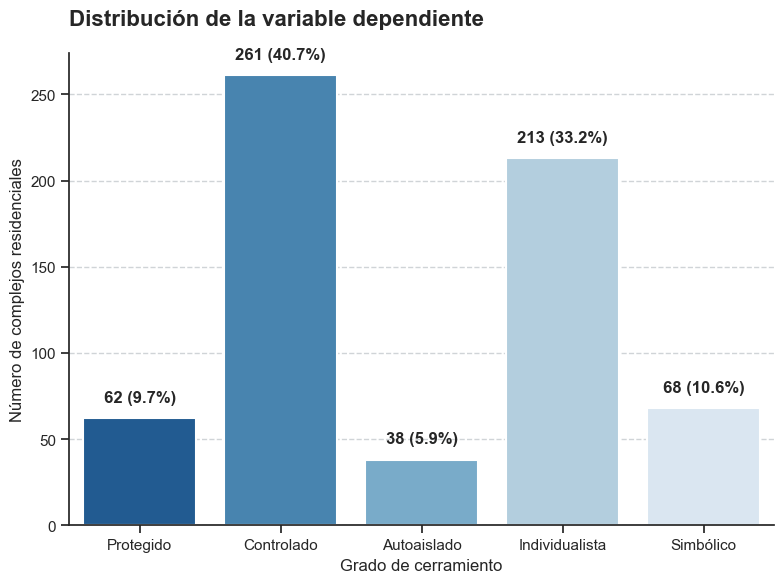

In [8]:
# # A column is created with the label for the EDA charts and tables.
map_label = mapping = {
    1: "Protegido",
    2: "Controlado",
    3: "Autoaislado",
    4: "Individualista",
    5: "Simbólico"
}
df["URB"] = df["URB"].astype(int)
df["URB_label"] = df["URB"].map(mapping)

# # The order is defined according to the degree of enclosure
orden_urb_label = ["Protegido", "Controlado", "Autoaislado", "Individualista", "Simbólico"]
# The variable is defined as categorical to display it ordered in visualizations and tables
df["URB_label"] = pd.Categorical(df["URB_label"],categories=orden_urb_label, ordered=True)

plot_univariate_distribution(df,"URB_label", title="Distribución de la variable dependiente", axis_label= "Grado de cerramiento", order=orden_urb_label)

Los grados de cerramiento predominantes son *Controlado* e *Individualista*, que representan el $40.7\%$ y el $33.2\%$ de los complejos residenciales, respectivamente. Las tres categorías restantes presentan una frecuencia considerablemente inferior: *Protegido* y *Simbólico* representan aproximadamente el $10%$ de los registros cada una, mientras que *Autoaislado* constituye la clase menos representada, con un $5.9\%$ de las observaciones. En conjunto, la distribución presenta un ratio de desbalanceo de $261:38$ entre la clase mayoritaria y la minoritaria.

La presencia de este desbalanceo debe considerarse en el diseño del protocolo experimental para evitar que los modelos desarrollen un sesgo hacia las clases mayoritarias. Dado que todas las categorías del grado de cerramiento tienen la misma relevancia en el problema de clasificación, la evaluación del rendimiento se realizará mediante métricas robustas frente al desbalanceo de clases y el entrenamiento incorporará mecanismos de aprendizaje sensibles al coste, con el objetivo de garantizar un tratamiento equilibrado de todas las clases.


<a id="variables_informativas_descripcion"></a>
# 3. Variables informativas o descriptivas

La base de datos incluye un conjunto de $30$ variables recopiladas por los autores con fines descriptivos. Estas variables permiten identificar los complejos residenciales a nivel catastral, ubicarlos geográficamente y caracterizarlos mediante información básica, como el número y tipo de viviendas, la superficie ocupada y la presencia de elementos comunitarios, entre otros atributos. Dado su carácter descriptivo, estas variables no forman parte del conjunto de variables predictoras empleado por los modelos de clasificación. Su utilización se limita a la identificación, contextualización y descripción de los complejos residenciales. En particular se hace uso de las siguientes variables:

* **Código del complejo completo (CC)**. Código de $8$ dígitos que identifica de forma única a cada complejo residencial. Se obtiene a partir de la concatenación del *código de municipio (CM)*, el *código de distrito (CD)* y el *código del complejo (CCOM)*, todos ellos disponibles en la base de datos. Este identificador se utiliza para referenciar de manera unívoca cada complejo residencial en el marco del proyecto.

In [9]:
# Convert CC column to int
df["CC"] = df["CC"].astype(int)

# Check unique values
es_unico = df["CC"].is_unique

if es_unico:
    print("The CC variable is a unique identifier in the database.")
else:
    print("There are duplicate values ​​in the CC variable; it cannot be used as a unique identifier.")

The CC variable is a unique identifier in the database.


* **Municipio (MUN)**. Nombre del municipio al que pertenece cada complejo residencial. En la base de datos se registran complejos residenciales pertenecientes a $32$ municipios, aproximadamente la mitad de los cuales se localizan en la ciudad de Granada, tal y como se muestra en la siguiente figura.

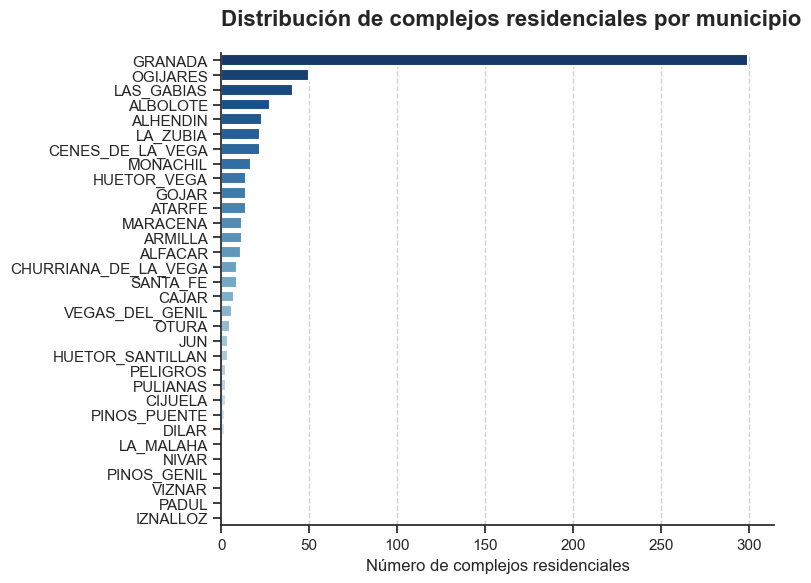

In [10]:
plot_univariate_distribution(df,"MUN", title="Distribución de complejos residenciales por municipio",
                              axis_label= "", show_values= False, orientation="horizontal", figsize=(8,6))

* **Coordenadas de latitud (LAT) y longitud (LON)**. Coordenadas geográficas expresadas en el sistema UTM bajo el sistema geodésico de referencia ETRS89 en la zona 30N (correspondiente al hemisferio norte, que abarca gran parte de la España peninsular occidental y central). Estas variables permiten la localización y representación cartográfica de los complejos residenciales.

A continuación se muestra la representación cartográfica de complejos residenciales pertenecientes a las cinco categorías de grado de cerramiento, indicando en cada caso el municipio y el identificador del complejo. Esta visualización se emplea como apoyo al análisis de interpretabilidad local, permitiendo contextualizar geográficamente los casos estudiados $^1$.

> $^1$ Aunque la representación cartográfica puede evidenciar determinados patrones de cerramiento, no constituye un criterio de clasificación directo, ya que muchas de las características urbanísticas no son observables visualmente.

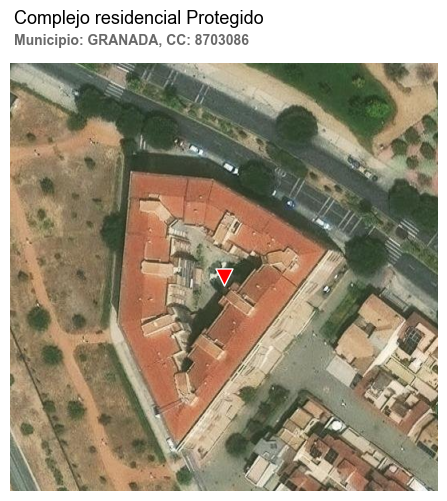

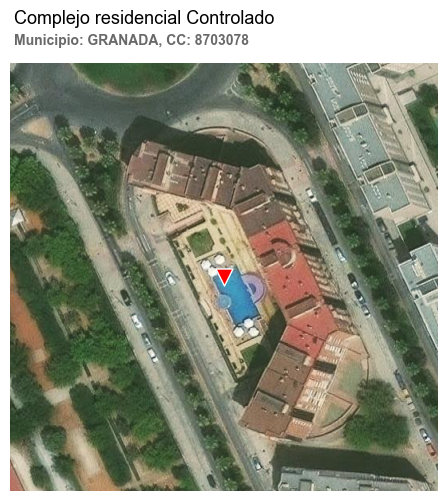

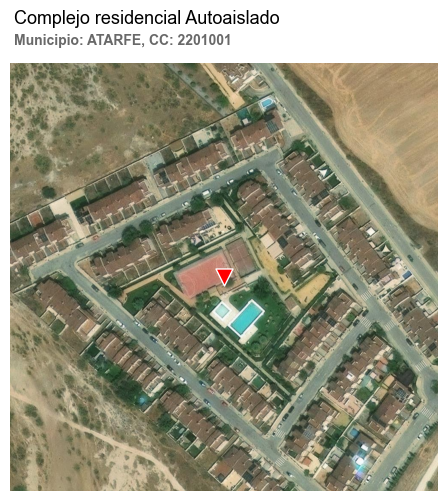

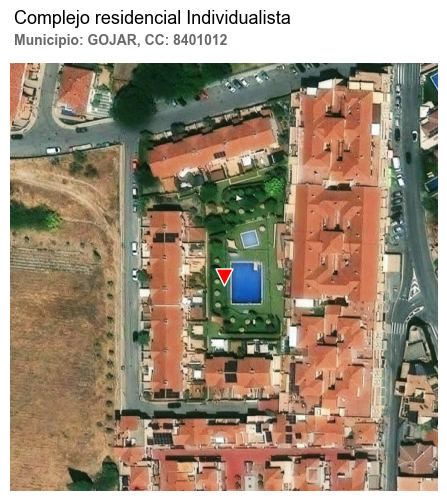

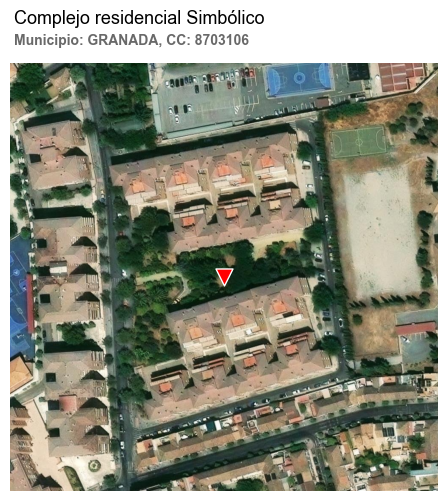

In [11]:
plot_individual_sample_map(cfg, df, 8703086, half_side=80)
plot_individual_sample_map(cfg, df, 8703078, half_side=80)
plot_individual_sample_map(cfg, df, 2201001, half_side=150)
plot_individual_sample_map(cfg, df, 8401012, half_side=100)
plot_individual_sample_map(cfg, df, 8703106, half_side=150)

<a id="variable_predictoras"></a>
# 4. Variables predictoras: características urbanas

La base de datos incluye $25$ variables predictoras que describen características de la morfología urbana relacionadas con el grado de cerramiento. A excepción de la variable de distancia, que presenta tres categorías, todas son variables de tipo categórico binario que toman los valores $0$ y $1$ para indicar la ausencia o presencia del elemento morfológico correspondiente.

El análisis exploratorio realizado en esta sección tiene como objetivo caracterizar individualmente cada variable independiente y evaluar su capacidad discriminativa respecto a la variable objetivo. Este análisis proporciona una primera aproximación a la complejidad del problema de clasificación e identifica relaciones relevantes que servirán como base de conocimiento en la fase de interpretabilidad de los modelos. Dada la naturaleza categórica de las variables, el análisis univariante se basa en el estudio de sus frecuencias absolutas y relativas, mientras que el análisis bivariante se centra en la evaluación de relaciones de asociación. En particular, se analiza cómo varía la distribución del grado de cerramiento (variable objetivo) en función de los distintos valores que toma cada característica.

El análisis bivariante se realiza mediante el test $\chi^2$ de Pearson y el estudio de tablas de contingencia. El test $\chi^2$ evalúa la existencia de asociación entre dos variables categóricas contrastando la hipótesis nula de independencia ($H_0$) frente a la alternativa de dependencia ($H_1$). La significación estadística del test se complementa con el coeficiente V de *Cramer*, que cuantifica la intensidad de la asociación. Las tablas de contingencia $^2$ muestran la distribución de la presencia (valor 1) y ausencia (valor 0) de cada característica en las distintas categorías del grado de cerramiento.

Los autores de la base de datos organizan las variables predictoras en seis bloques semánticos, que definen distintas dimensiones del grado de cerramiento. A lo largo del proyecto se hace referencia a esta organización, puesto que encapsula el conocimiento del dominio y facilita la comprensión de las variables, resultando especialmente útil en la fase de interpretabilidad de los modelos. En este sentido, el análisis exploratorio de esta sección se realiza de forma estructurada para cada uno de estos bloques semánticos.

> $^2$: Debido el desbalanceo de la variable objetivo, se han empleado tablas de contingencia normalizadas por columnas, de modo que cada categoría suma el $100\%$, lo que facilita la comparación entre grados de cerramiento al expresar directamente el porcentaje de complejos residenciales que presentan cada característica.


<a id="aspectos_estructurales"></a>
## 4.1 Aspectos estructurales

Las variables de este bloque semántico aportan información sobre la estructura viaria y el tipo de comercios que alberga el complejo residencial. A continuación se muestra el identificador y descripción de cada variable de este bloque:

* **CSS**. Calles sin salida.
* **CFS**. Calles en fondo de saco.
* **CPE**. Calles peatonales.
* **LIN**. Comercios internos.
* **LEX**. Comercios externos.

<a id="tipos_de_calles"></a>
### 4.1.1 Estructura viaria

Las variables *calles sin salida (CSS)*, *calles en fondo de saco (CFS)* y *calles peatonales (CPE)* describen la configuración de la red viaria interna y el nivel de accesibilidad al complejo residencial. Tanto las calles sin salida como las calles en fondo de saco se caracterizan porque el acceso y la salida se realizan a través de un único punto. En el primer caso, la continuidad de la vía queda interrumpida de forma abrupta, generalmente por un muro u otro elemento físico. En el segundo, la vía finaliza en un espacio de maniobra, como una rotonda o una plazoleta, que permite invertir el sentido de la marcha y abandonar el recinto por el mismo punto de acceso. Ambos tipos de vías pueden contribuir a incrementar el grado de cerramiento al actuar como elementos disuasorios que limitan indirectamente el tránsito de personas ajenas al complejo residencial. Por el contrario, la presencia de calles peatonales puede favorecer la permeabilidad del recinto, al facilitar el paso de no residentes y reducir la intensidad del cerramiento percibido.

La siguiente figura muestra la distribución conjunta de las variables *calles sin salida* (*CSS*) y *calles en fondo de saco* (*CFS*), analizadas conjuntamente por su relación semántica, y la distribución univariante de la variable *calles peatonales* (*CPE*).


=== TABLA DE FRECUENCIAS INDIVIDUALES (Valor = 1) ===
    Variable Original  Frecuencia Absoluta (1)  Porcentaje del Total (%)
CSS               CSS                       68                     10.59
CFS               CFS                       35                      5.45


=== TABLA DE FRECUENCIAS: CSS vs CFS ===
          Frecuencia Absoluta  Porcentaje (%)
CSS_CFS                                      
Ninguno                   547           85.20
Solo CSS                   60            9.35
Solo CFS                   27            4.21
Ambos                       8            1.25
--------------------------------------------------


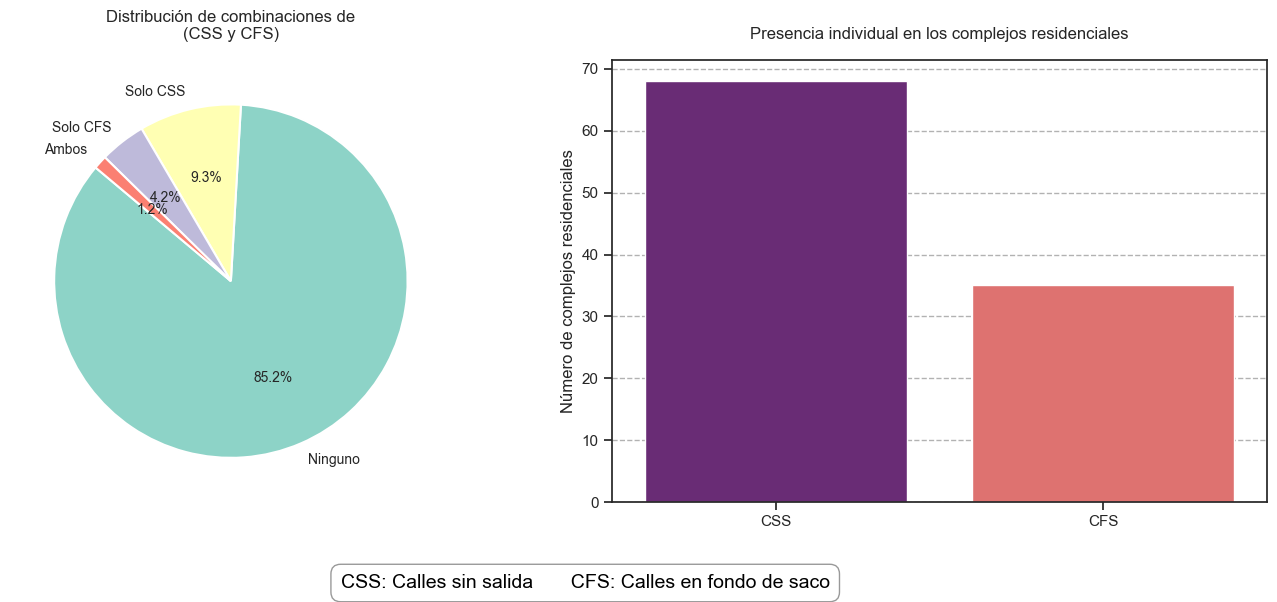

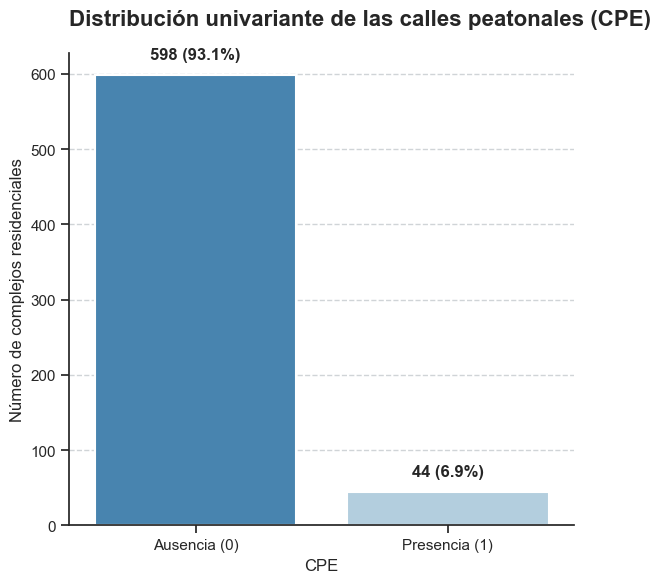

In [12]:
# Convert variables to integers
road_cols = ["CSS", "CFS", "CPE"]
df[road_cols] = df[road_cols].astype(int)
# Copy of dataframe for EDA of road structure variables
df_road = df[road_cols+["URB_label"]].copy()

df_road = analyze_binary_cooccurrence(df_road, ["CSS", "CFS"], {"CSS":"Calles sin salida", "CFS":"Calles en fondo de saco"})
plot_univariate_distribution(df_road, "CPE", title="Distribución univariante de las calles peatonales (CPE)",
                             dict_label={1: "Presencia (1)", 0: "Ausencia (0)"}, figsize=(6,6))

Las calles disuasorias constituyen un elemento poco frecuente en la base de datos: solo el $14.81\%$ de los complejos residenciales presenta *calles sin salida (CSS)* o *calles en fondo de saco (CFS)*, mientras que la presencia simultánea de ambas características es residual. De forma similar, las *calles peatonales (CPE)* también muestran una baja prevalencia, predominando su ausencia, como se observa en el gráfico de barras.

La siguiente figura presenta el análisis bivariante, mediante las tablas de contingencia y los resultados del test $\chi^2$ de Pearson, para las variables *calles sin salida* (*CSS*) y *calles en fondo de saco* (*CFS*), analizadas tanto de forma individual como conjunta con respecto al grado de cerramiento.

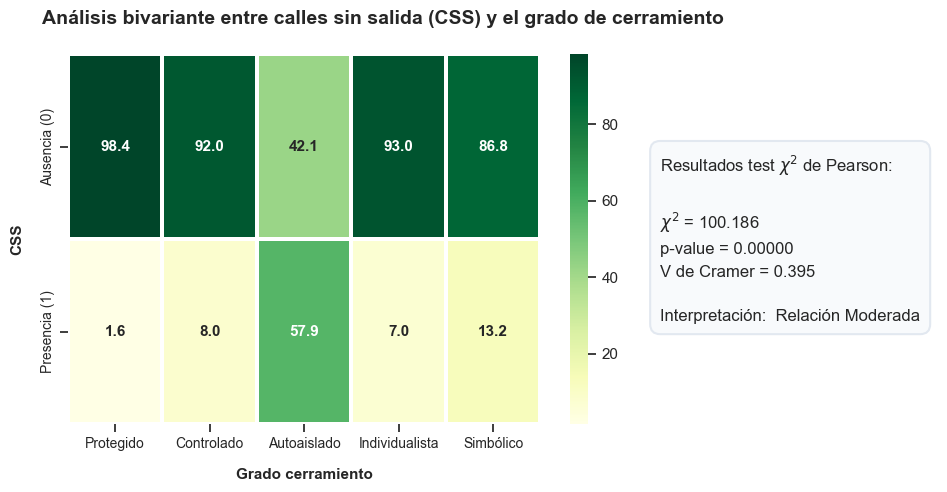

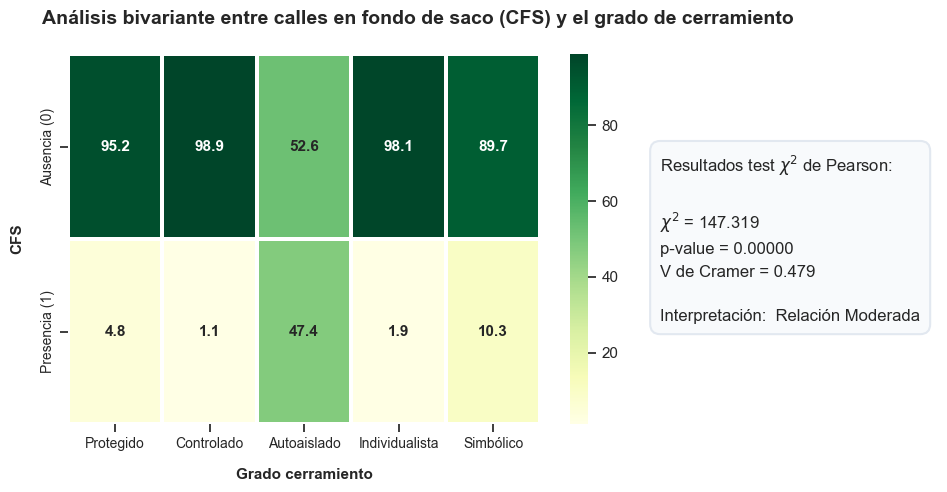

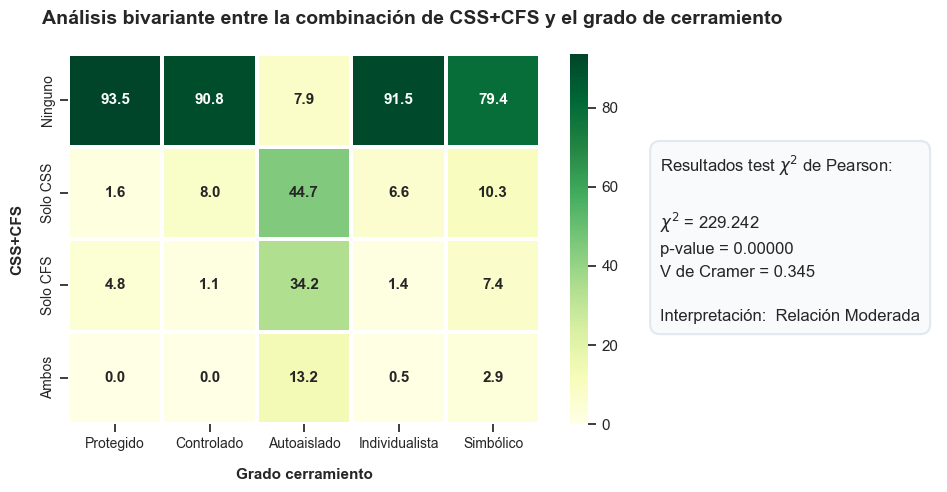

In [13]:
categorical_bivariate_analysis(df_road, "URB_label", "CSS", "Análisis bivariante entre calles sin salida (CSS) y el grado de cerramiento", name_var_dep="Grado cerramiento")
categorical_bivariate_analysis(df_road, "URB_label", "CFS", "Análisis bivariante entre calles en fondo de saco (CFS) y el grado de cerramiento", name_var_dep="Grado cerramiento")
categorical_bivariate_analysis(df_road, "URB_label", "CSS_CFS", "Análisis bivariante entre la combinación de CSS+CFS y el grado de cerramiento", name_var_dep="Grado cerramiento", name_var_ind="CSS+CFS")

El test $\chi^2$ de Pearson revela una asociación estadísticamente significativa entre ambas variables y el grado de cerramiento, al obtenerse un *p-value* inferior al nivel de significancia $\alpha=0.05$, criterio que se emplea de forma consistente a lo largo de todo el análisis.

Esta asociación se refleja en las tablas de contingencia. De forma individual, la ausencia de *calles sin salida (CSS)* y *calles en fondo de saco (CFS)* predomina en todos los grados de cerramiento ($\approx90\%$), salvo en la categoría *Autoaislado*, donde su presencia es claramente más frecuente. Este comportamiento se confirma al analizar ambas variables conjuntamente (siguiente figura) donde únicamente el $7.9%$ de los complejos residenciales *Autoaislados* no presenta ninguna de ellas. Estos resultados evidencian una fuerte asociación entre estas tipologías viarias y el grado de cerramiento *Autoaislado*, lo que indica que contribuyen al aislamiento característico de esta categoría.

En la siguiente figura se presenta el análisis bivariante entre las *calles peatonales (CPE)* y el grado de cerramiento.

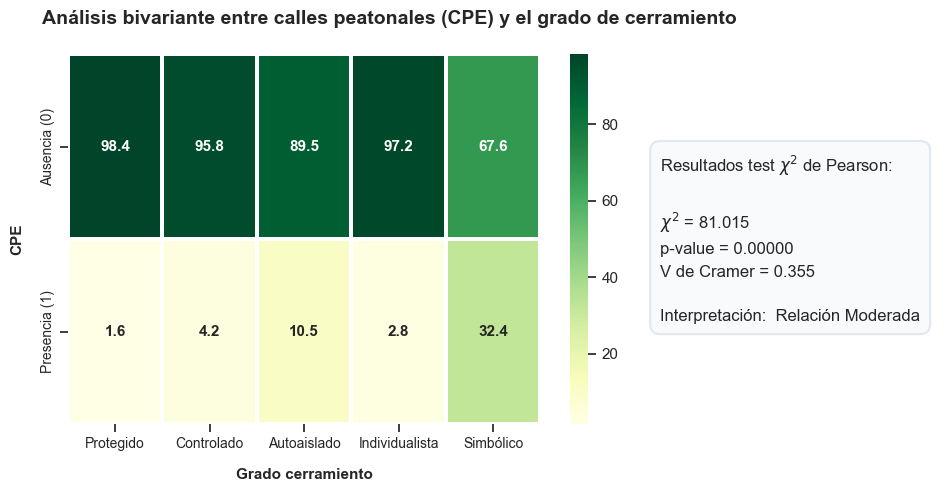

In [14]:
categorical_bivariate_analysis(df_road, "URB_label", "CPE", "Análisis bivariante entre calles peatonales (CPE) y el grado de cerramiento", name_var_dep="Grado cerramiento")

La asociación entre ambas variables es moderada, observándose una mayor presencia de calles peatonales en los complejos residenciales clasificados como *Simbólicos*. Esta relación es coherente con la interpretación semántica de la variable, ya que las calles peatonales favorecen la circulación de no residentes, reduciendo la intensidad del cerramiento percibido. Por el contrario, la presencia de calles peatonales es reducida en las categorías *Protegido*, *Controlado* e *Individualista*. No obstante, en la categoría *Autoaislado* se observa que un $10.5\%$ de los complejos residenciales incorpora este tipo de vías. Aunque esta proporción es inferior a la observada en los complejos *Simbólicos*, evidencia que las calles peatonales pueden coexistir con calles de naturaleza disuasoria. Esto pone de manifiesto la naturaleza multidimensional del grado de cerramiento, donde cada categoría tipológica surge de la interacción de múltiples características morfológicas que contribuyen en distinta medida a su definición.

<a id="tipos_de_comercios"></a>
### 4.1.2 Tipos de comercios

Las variables *LIN* y *LEX* codifican la presencia o ausencia de comercios internos y externos respectivamente. Este elemento es relevante para el grado de cerramiento puesto que su existencia implica, de algún modo, la presencia de clientes que habitualmente no son residentes del complejo residencial.

En la siguiente figura se muestra la distribución de las combinaciones de ambas variables.

=== TABLA DE FRECUENCIAS INDIVIDUALES (Valor = 1) ===
    Variable Original  Frecuencia Absoluta (1)  Porcentaje del Total (%)
LIN               LIN                       28                      4.36
LEX               LEX                      177                     27.57


=== TABLA DE FRECUENCIAS: LIN vs LEX ===
          Frecuencia Absoluta  Porcentaje (%)
LIN_LEX                                      
Ninguno                   454           70.72
Solo LIN                   11            1.71
Solo LEX                  160           24.92
Ambos                      17            2.65
--------------------------------------------------


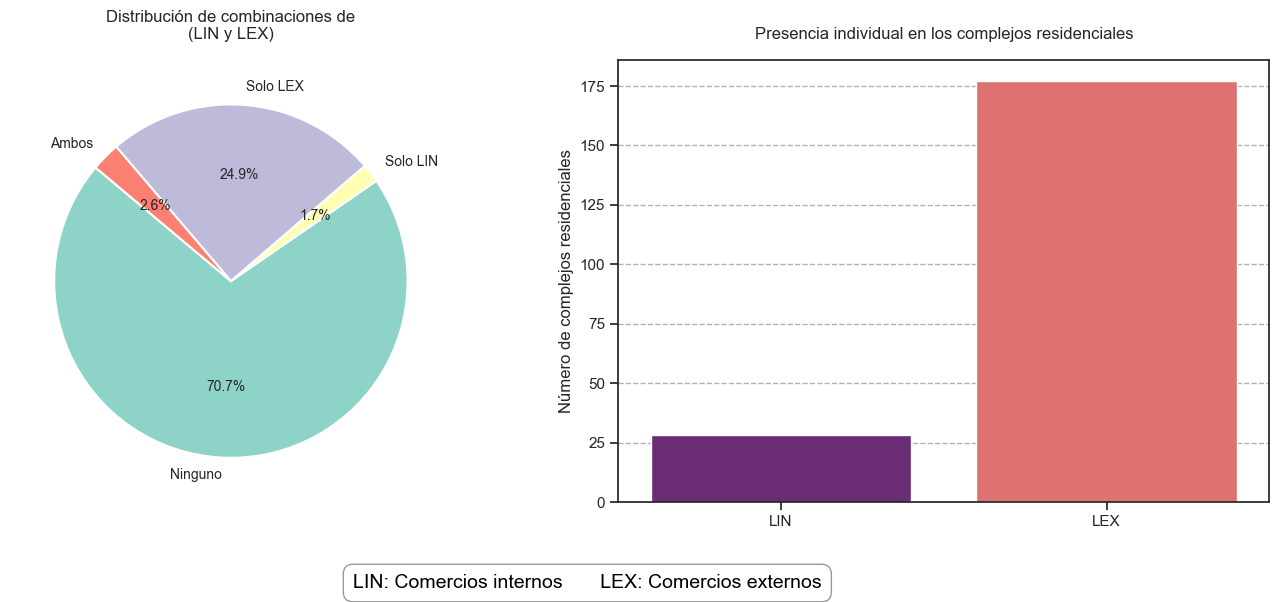

In [15]:
# Convert variables to integers
shops_cols = ["LIN", "LEX"]
df[shops_cols] = df[shops_cols].astype(int)
# Copy of dataframe for EDA of shop type variables
df_shops = df[shops_cols+["URB_label"]].copy()
df_shops = analyze_binary_cooccurrence(df_shops, ["LIN", "LEX"], {"LIN":"Comercios internos", "LEX":"Comercios externos"})

Los complejos residenciales con algún tipo de actividad comercial representan el $29.2\%$ de la base de datos, predominando aquellos con comercios ubicados en el exterior del complejo. Esto resulta consistente con la lógica funcional de estos establecimientos, ya que su ubicación en espacios más accesibles favorece la captación de clientes y el desarrollo de su actividad. 

En la siguiente figura se presenta el análisis bivariante entre los tipos de comercio y el grado de cerramiento. Ambas variables muestran una asociación estadísticamente significativa con la variable objetivo, aunque presentan patrones de asociación diferenciados.

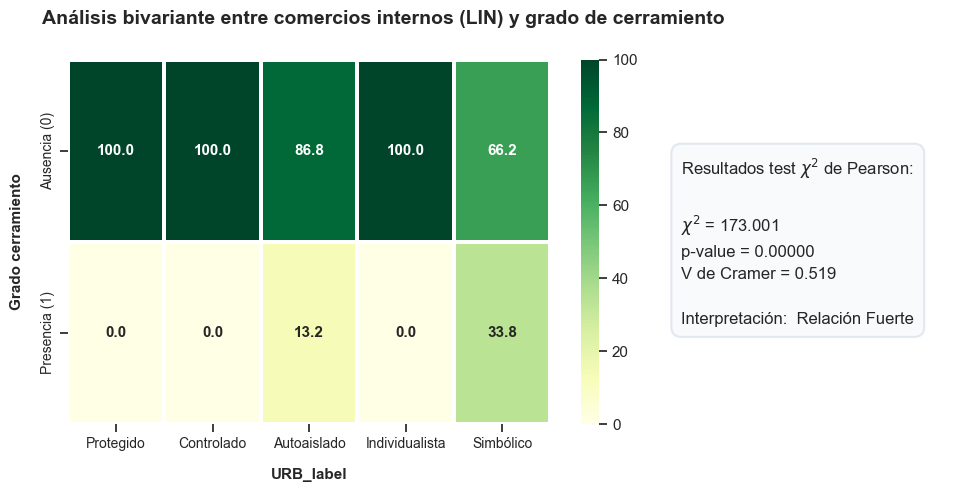

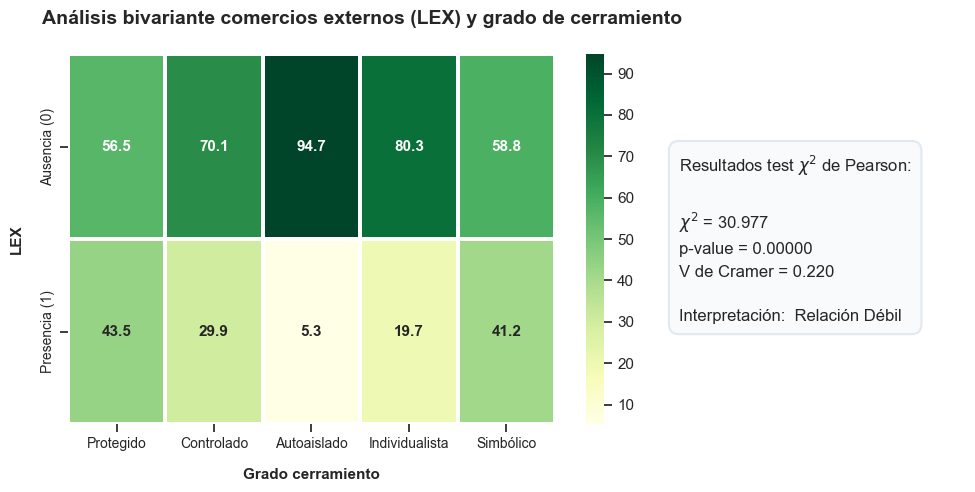

In [16]:
categorical_bivariate_analysis(df_shops, "URB_label", "LIN", "Análisis bivariante entre comercios internos (LIN) y grado de cerramiento", name_var_ind="Grado cerramiento")
categorical_bivariate_analysis(df_shops, "URB_label", "LEX", "Análisis bivariante comercios externos (LEX) y grado de cerramiento", name_var_dep="Grado cerramiento")

Los *comercios internos (LIN)* aparecen únicamente en las categorías *Simbólico* y *Autoaislado*, estando ausentes en el resto de grados de cerramiento. En cambio, los *comercios externos (LEX)* presentan distribuciones similares entre las distintas categorías, salvo en *Autoaislado*, donde solo están presentes en el $5.3\%$ de los complejos residenciales. Estas asociaciones reflejan que los *comercios internos* están estrechamente vinculados a la accesibilidad y permeabilidad del complejo residencial, por lo que se concentran en aquellas tipologías donde la interacción con no residentes resulta más frecuente.

Por el contrario, los *comercios externos* presentan una menor dependencia respecto al grado de cerramiento al localizarse fuera de los límites del complejo. La ausencia de estos establecimientos en la categoría *Autoaislado* podría estar relacionada con el carácter aislado de estos desarrollos respecto al tejido urbano circundante.

<a id="distancia"></a>
## 4.2 Distancia al núcleo úrbano principal

El bloque semántico ```*Distancia al núcleo urbano principal*'' está compuesto por la variable *DIS*, que caracteriza la localización del complejo residencial respecto al núcleo urbano principal más cercano. Se trata de una variable categórica con tres valores enteros codificados de la siguiente forma:

* **1. Aislado**. El complejo residencial se encuentra a una distancia igual o superior a un kilómetro del núcleo urbano principal más cercano.

* **2. Separado**. El complejo residencial se sitúa entre medio kilómetro y un kilómetro del núcleo urbano principal, existiendo una discontinuidad física, aunque mantiene una relación funcional con el tejido urbano.

* **3. Integrado**. El complejo residencial se encuentra conectado de forma continua al tejido urbano, formando parte del núcleo urbano principal.

La siguiente figura muestra la distribución de la variable *DIS*, donde destaca el predominio de los complejos residenciales integrados en el núcleo urbano, que representan el $83.5\%$ de los registros.

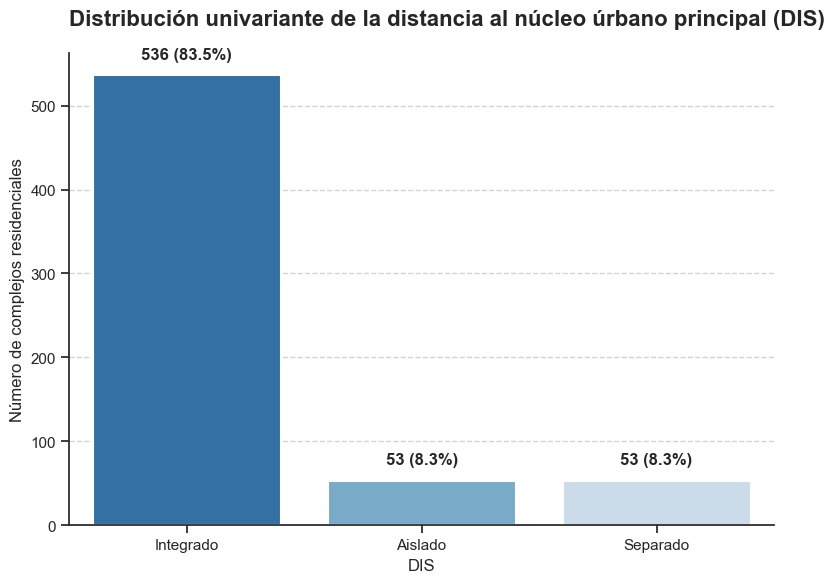

In [17]:
plot_univariate_distribution(df, "DIS", 
                            dict_label={1:"Aislado", 2: "Separado", 3: "Integrado"},
                            title="Distribución univariante de la distancia al núcleo úrbano principal (DIS)")

La siguiente figura presenta su análisis bivariante respecto al grado de cerramiento.

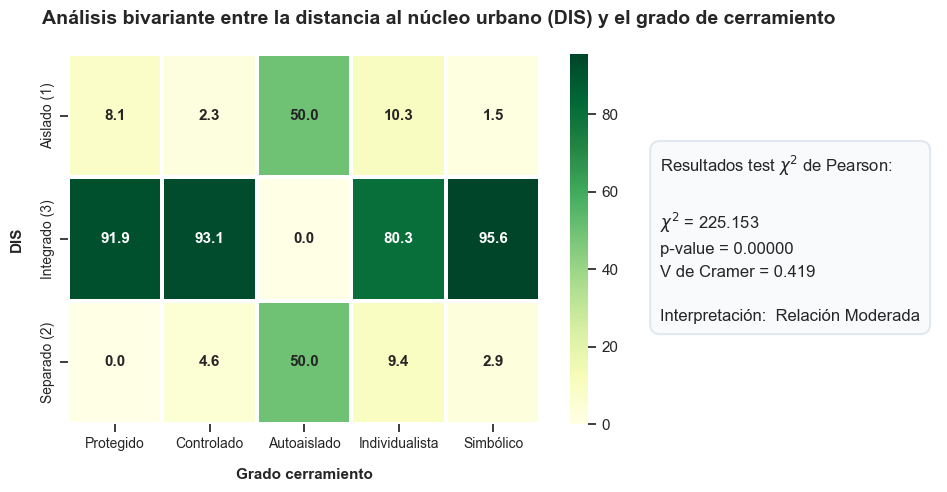

In [18]:
df_dist = df.copy()
df_dist["DIS"] = df_dist["DIS"].map({1:"Aislado (1)", 2: "Separado (2)", 3: "Integrado (3)"})
categorical_bivariate_analysis(df_dist, "URB_label", "DIS", "Análisis bivariante entre la distancia al núcleo urbano (DIS) y el grado de cerramiento", name_var_dep="Grado cerramiento")

El test $\chi^2$ de Pearson rechaza la hipótesis de independencia, indicando la existencia de una asociación significativa. Esta relación está determinada principalmente por el comportamiento de la categoría *Autoaislado*, cuya distribución difiere notablemente del resto de tipologías. No existen complejos residenciales *Autoaislados* integrados en el núcleo urbano principal, por lo que este grado de cerramiento queda asociado a las categorías "Aislado" y `Separado'' con una proporción del $50\%$.

Desde una perspectiva urbanística, este resultado sugiere que el grado de cerramiento *Autoaislado* no está definido únicamente por la presencia de elementos disuasorios, sino también por una localización geográfica desvinculada del tejido urbano. En consecuencia, la categoría ``Integrado'' de la variable *DIS* presenta una fuerte asociación con la ausencia de este grado de cerramiento, constituyendo una característica importante para discriminarlo del resto.

Aunque la categoría "Integrado" representa una menor distancia al núcleo urbano que las categorías `*Aislado*'' y ```*Separado*'', estas últimas no establecen una relación ordinal clara entre sí. Por tanto, la variable *DIS* se incorpora al conjunto de datos mediante una codificación *dummy (one-hot encoding)*, evitando asumir una relación de orden inexistente entre sus categorías. Esta transformación genera una variable binaria indicadora por cada categoría original, tomando el valor $1$ cuando el complejo residencial pertenece a dicha categoría y $0$ en caso contrario. Las variables resultantes son:

* **DIS_1**. Toma el valor $1$ si $DIS=1$ (complejo residencial aislado) y $0$ en caso contrario.

* **DIS_2**. Toma el valor $1$ si $DIS=2$ (complejo residencial separado) y $0$ en caso contrario.

* **DIS_3**. Toma el valor $1$ si $DIS=3$ (complejo residencial integrado) y $0$ en caso contrario.


In [19]:
# Creating dummy variables from DIS variable
dummies = pd.get_dummies(df["DIS"], prefix="DIS").astype(int)
df = pd.concat([df, dummies], axis=1)
print("First five rows of the dataframe (DIS variable and One-Hot encoding):")
print(df[["DIS","DIS_1","DIS_2","DIS_3"]].head())

First five rows of the dataframe (DIS variable and One-Hot encoding):
   DIS  DIS_1  DIS_2  DIS_3
0    1      1      0      0
1    1      1      0      0
2    1      1      0      0
3    1      1      0      0
4    1      1      0      0


<a id="elementos_cerramiento"></a>
## 4.3 Elementos de cerramiento

El bloque semántico ''*Elementos de cerramiento*'' agrupa variables que codifican la presencia o ausencia de elementos urbanísticos asociados a la delimitación física del complejo residencial. A continuación se muestra el identificador y descripción de las variables de este bloque:
* **VER**. Verjas o Vallas.
* **MUR**. Muros.
* **CAD**. Cadenas.
* **BOL**. Bolardos.
* **ARB**. Arbustos.
* **CPP**. Carteles de propiedad privada.

La siguiente figura muestra su frecuencia de aparición. Un complejo residencial puede presentar simultáneamente varios elementos de cerramiento distintos.

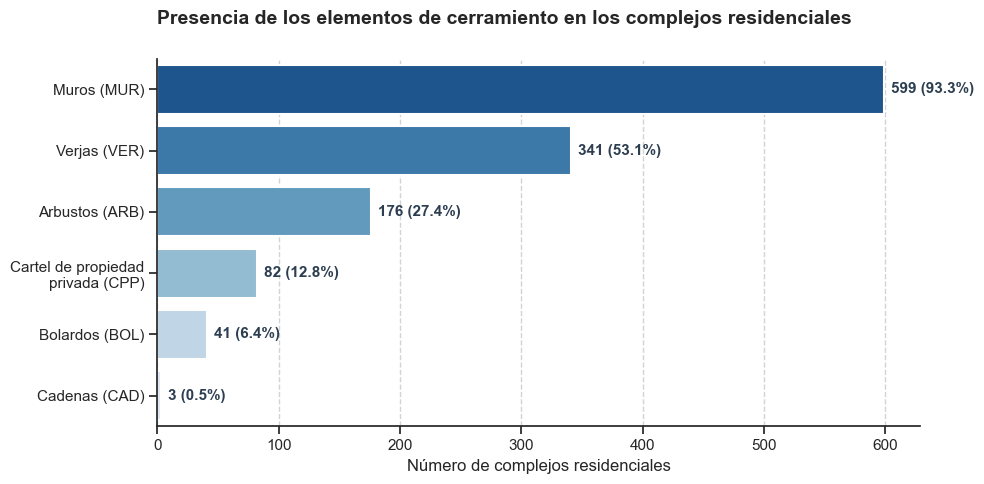

In [20]:
# Convert variables to integers
enclosure_cols = ["VER", "MUR", "CAD", "BOL", "ARB", "CPP"]
df[enclosure_cols] = df[enclosure_cols].astype(int)
# Copia de dataframe para EDA de las variables de este bloque
df_enclosure = df[enclosure_cols+["URB_label"]].copy()
plot_variable_occurrences(df_enclosure, enclosure_cols, title="Presencia de los elementos de cerramiento en los complejos residenciales",
                               dict_label={
                                   "MUR": "Muros (MUR)",
                                   "VER": "Verjas (VER)",
                                   "ARB": "Arbustos (ARB)",
                                   "CPP": "Cartel de propiedad\nprivada (CPP)",
                                   "BOL": "Bolardos (BOL)",
                                   "CAD": "Cadenas (CAD)"
                               })

Los *muros (MUR)* y las *verjas (VER)* son los elementos de cerramiento con mayor presencia en la base de datos. Desde una perspectiva urbanística, ambos corresponden a cerramientos de tipo "duro", al establecer una separación física entre el espacio residencial y el entorno exterior. Por el contrario, el resto de elementos se consideran cerramientos `blandos'', al desempeñar principalmente una función simbólica o disuasoria. Los *arbustos (ARB)*, *carteles de propiedad privada (CPP)* y *bolardos (BOL)* presentan una menor frecuencia, aunque con suficiente variabilidad para su análisis. En cambio, la variable *cadenas (CAD)* muestra una presencia residual, apareciendo únicamente en el $0.5\%$ de los complejos residenciales, lo que podría limitar su capacidad predictiva.

Las siguientes figuras muestran el análisis bivariante entre las variables *muros (MUR)* y *verjas (VER)*, respectivamente, y el grado de cerramiento.

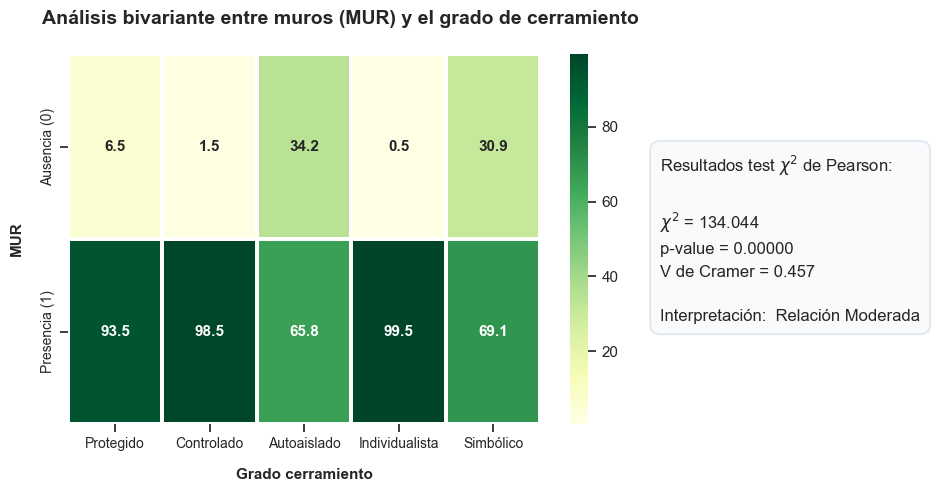

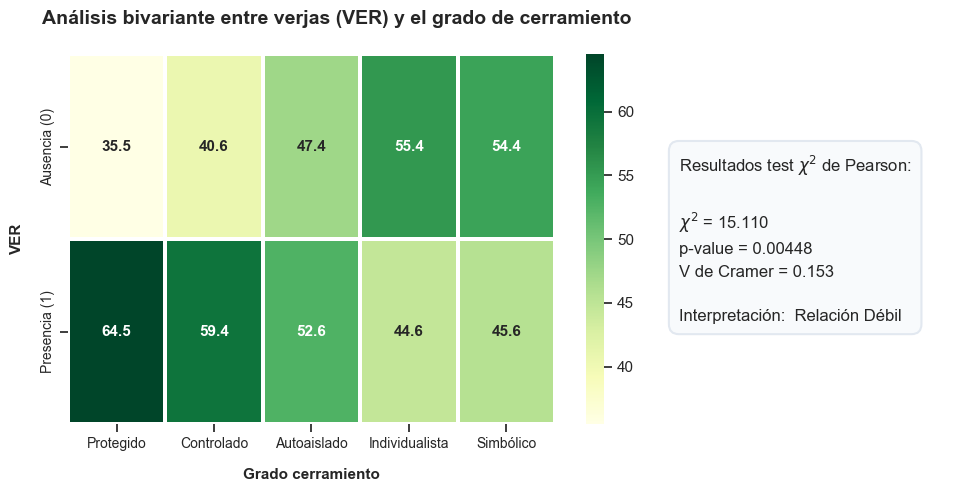

In [21]:
categorical_bivariate_analysis(df_enclosure, "URB_label", "MUR", "Análisis bivariante entre muros (MUR) y el grado de cerramiento", name_var_dep="Grado cerramiento")
categorical_bivariate_analysis(df_enclosure, "URB_label", "VER", "Análisis bivariante entre verjas (VER) y el grado de cerramiento", name_var_dep="Grado cerramiento")

La tabla de contingencia muestra una elevada presencia de *muros (MUR)* en todas las categorías de cerramiento. No obstante, se observa una menor frecuencia en los complejos *Autoaislados* y *Simbólicos*, donde este elemento está presente en aproximadamente el $70\%$ de los casos, frente a valores superiores al $90\%$ en el resto de tipologías. Este patrón de asociación indica una relación moderada entre la ausencia de muros y los grados de cerramiento *Autoaislado* y *Simbólico*.

Por el contrario, las *verjas (VER)* presentan una asociación débil con el grado de cerramiento. Como se observa en la tabla de contingencia, la distribución entre presencia y ausencia permanece aproximadamente equilibrada en la mayoría de categorías, con proporciones cercanas al $50%$.

En las siguientes figuras se muestra el análisis bivariante entre las variables *arbustos (ARB)*, *bolardos (BOL)*, *carteles de propiedad privada (CPP)* y *cadenas (CAD)* respectivamente, y el grado de cerramiento.

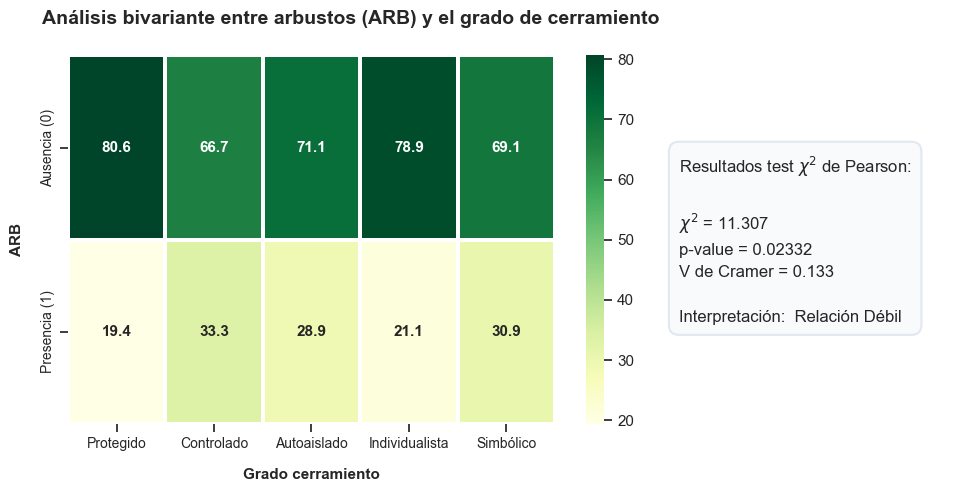

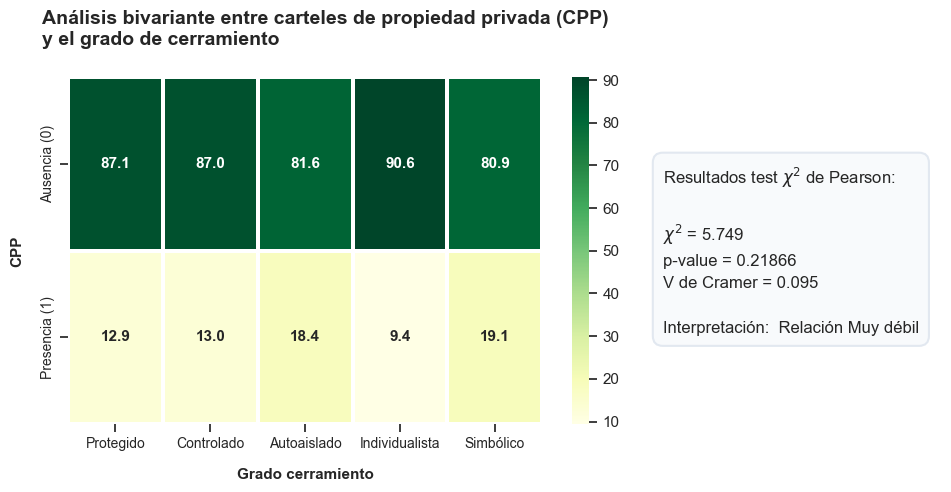

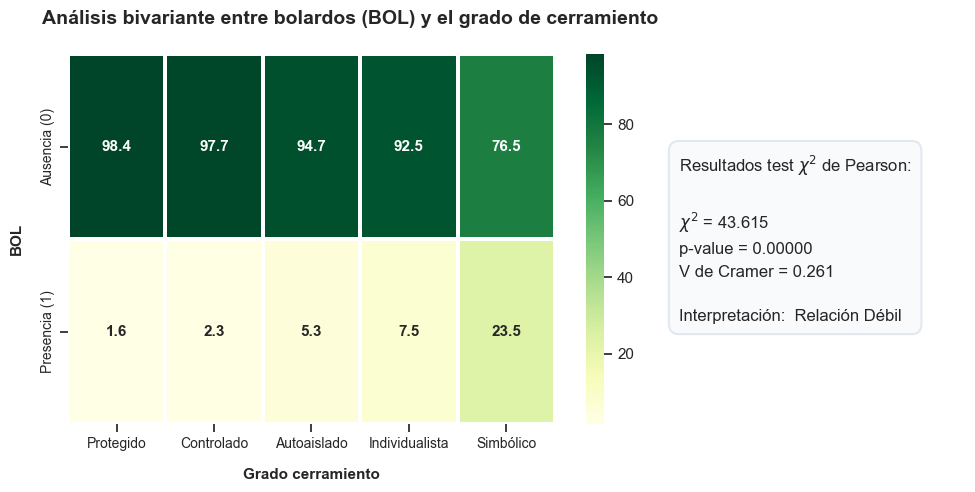

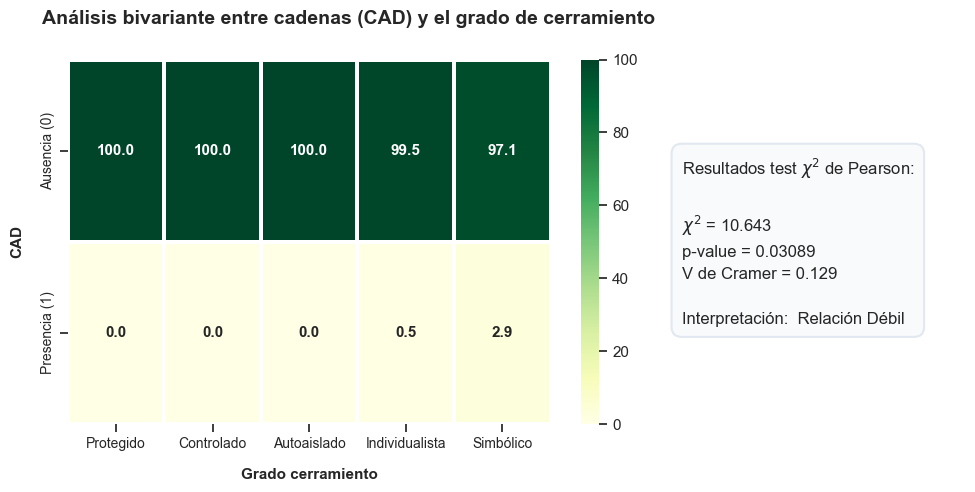

In [22]:
categorical_bivariate_analysis(df_enclosure, "URB_label", "ARB", "Análisis bivariante entre arbustos (ARB) y el grado de cerramiento", name_var_dep="Grado cerramiento")
categorical_bivariate_analysis(df_enclosure, "URB_label", "CPP", "Análisis bivariante entre carteles de propiedad privada (CPP)\ny el grado de cerramiento", name_var_dep="Grado cerramiento")
categorical_bivariate_analysis(df_enclosure, "URB_label", "BOL", "Análisis bivariante entre bolardos (BOL) y el grado de cerramiento", name_var_dep="Grado cerramiento")
categorical_bivariate_analysis(df_enclosure, "URB_label", "CAD", "Análisis bivariante entre cadenas (CAD) y el grado de cerramiento", name_var_dep="Grado cerramiento")

El análisis de las tablas de contingencia y los resultados del test $\chi^2$ de Pearson muestran una asociación débil entre estas características y la variable objetivo, ya que ninguna presenta una distribución claramente diferenciada en ningún grado de cerramiento. El test $\chi^2$ no rechaza la hipótesis de independencia para los *carteles de propiedad privada (CPP)*, mientras que para *arbustos (ARB)* y *cadenas (CAD)* el nivel de significancia obtenido se encuentra próximo al umbral establecido $\alpha=0.05$. La única asociación estadísticamente significativa, de forma clara, corresponde a los *bolardos (BOL)*, cuya presencia muestra una mayor concentración en los complejos residenciales *Simbólicos*.

Estos resultados ponen de manifiesto que la relación entre los elementos de cerramiento y el grado de cerramiento es más compleja de lo esperado en base al conocimiento del dominio, ya que no existen asociaciones fuertes lo que indica que la capacidad discriminativa individual de este bloque de variables es reducida.

<a id="puntos_de_acceso"></a>
## 4.4 Puntos de acceso

El bloque semántico ''*Puntos de acceso*'' agrupa las variables que describen las distintas formas de acceso al complejo residencial. Se distinguen dos tipos de accesos:

* **Accesos comunes**. Utilizados de forma compartida por los residentes para acceder al complejo residencial.

* **Accesos individuales**. Permiten el acceso directo a las zonas comunes desde cada vivienda en urbanizaciones unifamiliares o mediante los distintos portales en complejos residenciales de bloques.

A continuación se muestra el identificador y descripción de las variables de este bloque:
* **PVI**. Entrada por vivienda.
* **PBL**. Entrada por bloque.
* **COM**. Entrada común a la urbanización
* **COMS**. Varias entradas comunes a la urbanización.

La siguiente figura muestra la frecuencia de aparición de cada tipo de acceso. Un complejo residencial puede presentar simultáneamente varios puntos de acceso diferentes. 

En términos generales, la distribución es relativamente equilibrada, aunque se observa un predominio de los accesos comunes (*COM* y *COMS*) frente a los accesos individuales (*PVI* y *PBL*).

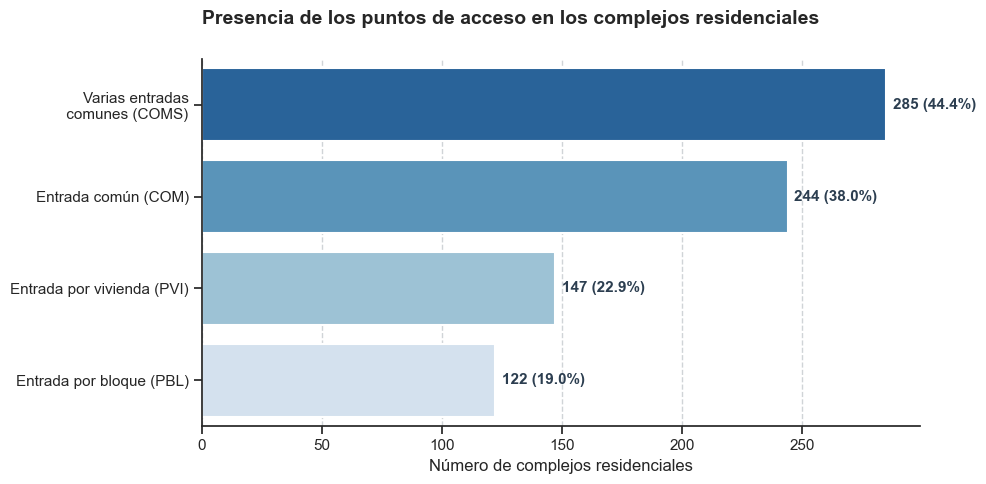

In [23]:
# # Convert variables to integers
access_cols = ["PVI", "PBL", "COM", "COMS"]
df[access_cols] = df[access_cols].astype(int)
# Copy of dataframe for EDA of the variables in this block
df_access = df[access_cols+["URB_label"]].copy()
plot_variable_occurrences(df_access, access_cols, title="Presencia de los puntos de acceso en los complejos residenciales",
                               dict_label={
                                        "PVI": "Entrada por vivienda (PVI)",
                                        "PBL": "Entrada por bloque (PBL)",
                                        "COM": "Entrada común (COM)",
                                        "COMS": "Varias entradas\n comunes (COMS)"})

En la siguiente figura se presenta el análisis bivariante entre los accesos individuales y el grado de cerramiento.

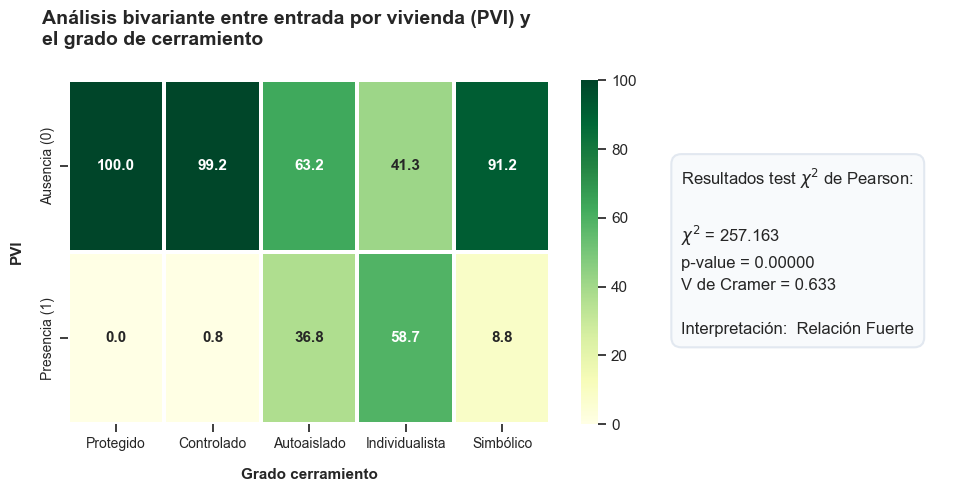

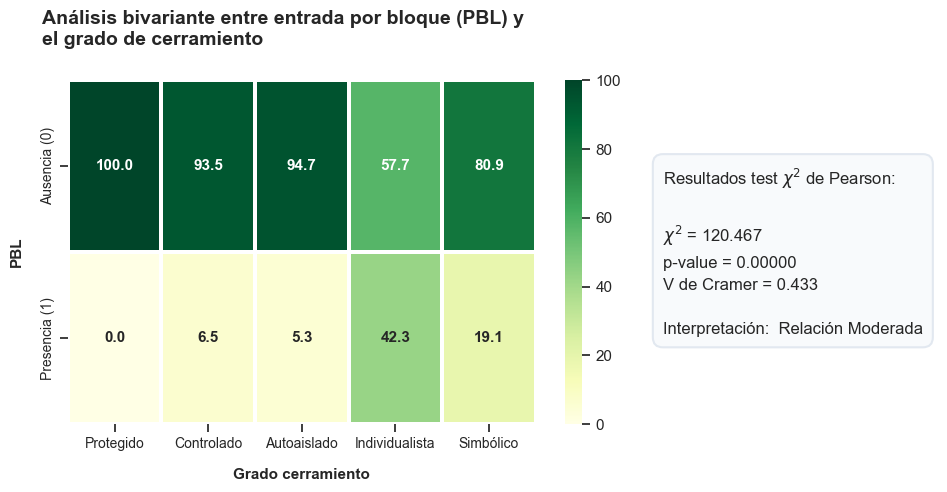

In [24]:
categorical_bivariate_analysis(df_access, "URB_label", "PVI", "Análisis bivariante entre entrada por vivienda (PVI) y\nel grado de cerramiento", name_var_dep="Grado cerramiento")
categorical_bivariate_analysis(df_access, "URB_label", "PBL", "Análisis bivariante entre entrada por bloque (PBL) y\nel grado de cerramiento", name_var_dep="Grado cerramiento")

Los resultados del test $\chi^2$ de Pearson indican la existencia de una asociación significativa entre ambas variables y la variable objetivo. Las tablas de contingencia muestran que la *entrada por vivienda (PVI)* presenta una mayor presencia en los complejos residenciales *Autoaislados* e *Individualistas*, mientras que la *entrada por bloque (PBL)* se concentra principalmente en la categoría *Individualista*.


En la siguiente figura se muestra el análisis bivariante entre los accesos comunes y el grado de cerramiento.

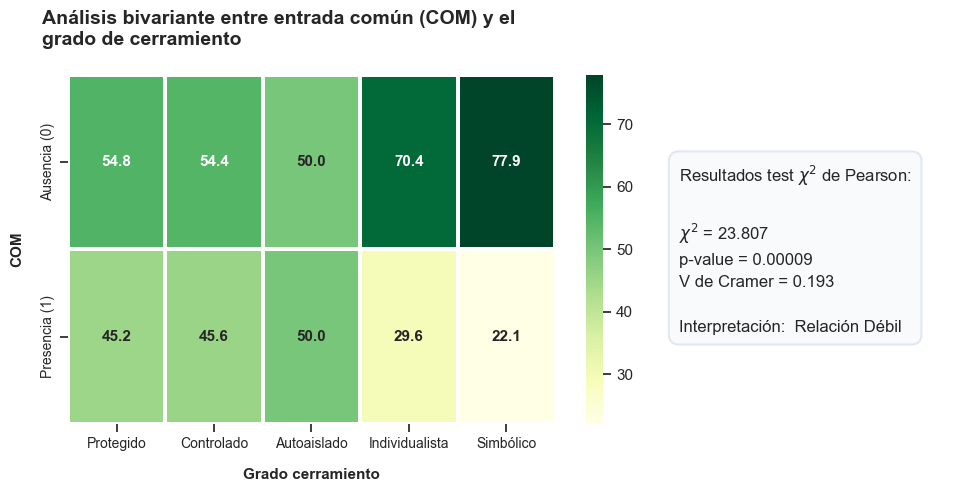

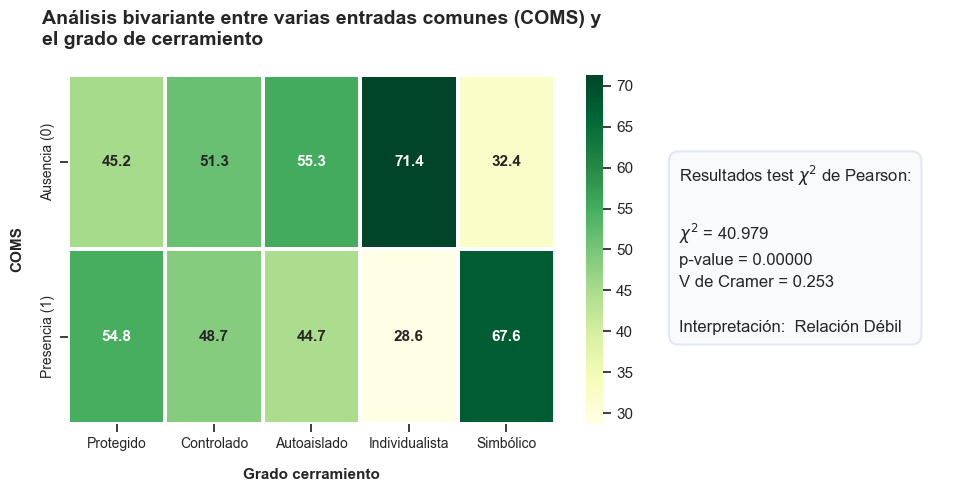

In [25]:
categorical_bivariate_analysis(df_access, "URB_label", "COM", "Análisis bivariante entre entrada común (COM) y el\ngrado de cerramiento", name_var_dep="Grado cerramiento")
categorical_bivariate_analysis(df_access, "URB_label", "COMS", "Análisis bivariante entre varias entradas comunes (COMS) y\nel grado de cerramiento", name_var_dep="Grado cerramiento")

En este caso ambas variables presentan una asociación débil con la variable objetivo. En las categorías *Protegido*, *Controlado* y *Autoaislado*, las distribuciones de presencia y ausencia se mantienen próximas al equilibrio ($\approx50\%$), lo que limita su capacidad discriminativa individual. Por el contrario, en la categoría *Individualista*, la presencia de accesos comunes es poco frecuente, reforzando el patrón observado para los accesos individuales en las tablas de contingencia de las siguientes figuras.

En conjunto, el análisis bivariante de las variables del bloque "*Puntos de acceso*'" revela que el grado de cerramiento *Individualista* se caracteriza por configuraciones de acceso individuales, mientras que *Protegido*, *Controlado* y *Simbólico* presentan un mayor predominio de accesos comunes. La categoría *Autoaislado* muestra un comportamiento intermedio, combinando accesos individuales (*PVI*) y comunes (*COM* y *COMS*) en proporciones similares.

La similitud observada entre las asociaciones de *COM* y *COMS* con el grado de cerramiento, junto con su significado semántica, podría indicar cierta redundancia entre ambas variables. No obstante, este comportamiento no se mantiene en todas las categorías. En los complejos *Simbólicos*, la presencia de *varias entradas comunes (COMS)* alcanza el $67.6%$, mientras que la presencia de una única *entrada común (COM)* se reduce al $22.1\%$. Esta diferencia muestra que ambas variables representan configuraciones de acceso diferenciadas y, por tanto, aportan información complementaria al modelo.

<a id="via_publica"></a>
## 4.5 Uso de la vía pública

El bloque semántico "*Uso de la vía pública*" agrupa variables que describen el tipo de uso y dominio de las vías interiores o adyacentes al complejo residencial. A continuación se muestra el identificador y descripción de las variables de este bloque:
* **PPU**. Dominio y uso público: Viales de libre circulación.
* **PPR**. Dominio y uso privado: Uso reservado a residentes y personas autorizadas.
* **PRE**. Dominio privado de uso público restringido: Permiten el acceso a personas ajenas de forma limitada o bajo determinadas condiciones como el horario de apertura de los comercios situados en el interior del complejo.

Estas variables son mutuamente excluyentes, por lo que únicamente puede existir un tipo de uso y dominio de la vía1. En aquellos casos en los que no existen vías interiores ni vías asociadas al entorno inmediato, todas las variables están ausentes y toman simultáneamente el valor $0$.

La siguiente figura muestra la distribución del tipo de uso de la vía en la base de datos.

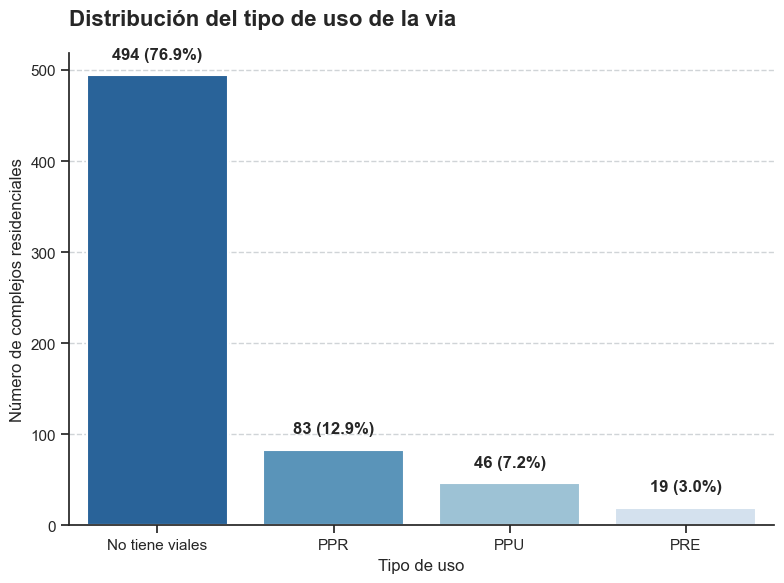

In [26]:
# Convert variables to integers
viales_cols = ["PPU", "PRE", "PPR"]
df[viales_cols] = df[viales_cols].astype(int)
# Copy of dataframe for EDA of the variables in this block
df_viales = df[viales_cols+["URB_label"]].copy()

def codificar_viales(row):
    # Active variables are detected (value 1)
    tipos_viales = row[viales_cols][row[viales_cols] == 1].index.tolist()

    # Residential complexes without roads
    if len(tipos_viales) == 0:
        return "No tiene viales"
    elif len(tipos_viales) == 1:
        return tipos_viales[0]
    else:
        return "Más de un tipo de vial (Warning)"

df_viales["Tipo de uso"] = df_viales.apply(codificar_viales, axis=1)
plot_univariate_distribution(df_viales, "Tipo de uso",
                             title="Distribución del tipo de uso de la via")

Se trata de una característica poco frecuente, ya que la mayoría de los complejos residenciales no presenta viales asociados. Entre aquellos que sí disponen de vías, predominan las de *dominio y uso privado (PPR)*, mientras que los usos con algún grado de apertura público tienen una menor presencia, especialmente el *dominio privado con uso público restringido (PRE)*.

En la siguiente figura se presenta el análisis bivariante entre el tipo de uso de la vía y el grado de cerramiento.

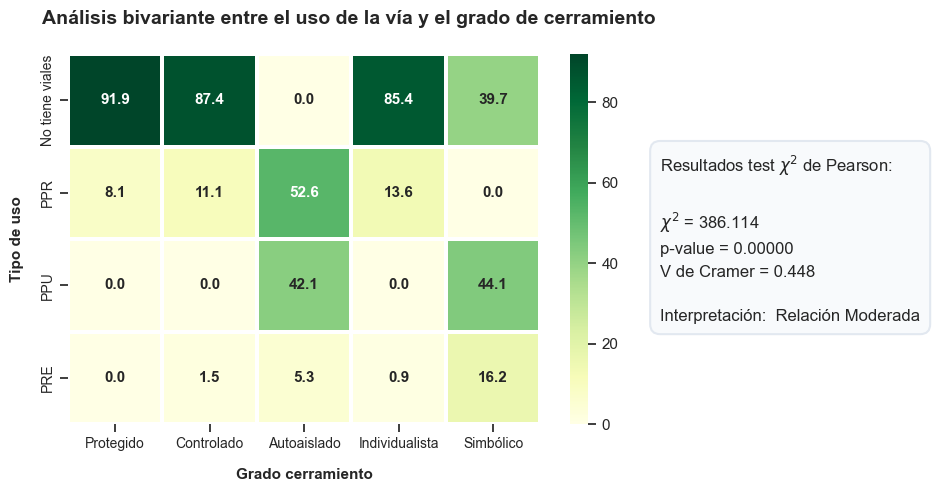

In [27]:
categorical_bivariate_analysis(df_viales, "URB_label", "Tipo de uso", "Análisis bivariante entre el uso de la vía y el grado de cerramiento", name_var_dep="Grado cerramiento")

La tabla de contingencia muestra que los grados de cerramiento *Protegido*, *Controlado* e *Individualista* presentan una mayor tendencia a no disponer de viales, mientras que los distintos tipos de uso de la vía se concentran principalmente en los complejos *Autoaislados* y *Simbólicos*.

En la categoría *Autoaislado*, las configuraciones de uso de la vía son heterogéneas, con una presencia similar de vías de *dominio y uso privado (PPR)* y de *dominio y uso público (PPU)*. Esta asociación indica que en esta tipología pueden coexistir modelos viarios opuestos, desde espacios completamente privados hasta espacios abiertos al uso público. Esto sugiere que, en la categoría *Autoaislado*, los elementos disuasorios y el aislamiento respecto al núcleo urbano tienen mayor relevancia en la caracterización del grado de cerramiento que el tipo de uso de la vía.

Por el contrario, los complejos *Simbólicos* presentan configuraciones vinculadas al uso público, ya sea mediante vías de *dominio y uso público (PPU)* o de *dominio privado con uso público restringido (PRE)*, sin observarse casos con un régimen completamente privado. Esta relación es consistente con una menor intensidad de cerramiento.

<a id="seguridad"></a>
## 4.6 Seguridad y vigilancia

El bloque semántico "*Seguridad y vigilancia*" agrupa variables que representan la presencia o ausencia de servicios y mecanismos de control. A continuación se muestra el identificador y descripción de las variables de este bloque:
* **GSE**. Guardia de seguridad.
* **CSE**. Cámaras de seguridad.
* **BSE**. Barrera de seguridad.
* **ASE**. Alarma de seguridad.

La siguiente figura muestra su frecuencia de aparición. Un complejo residencial puede presentar simultáneamente servicios y mecanismos de seguridad diferentes.

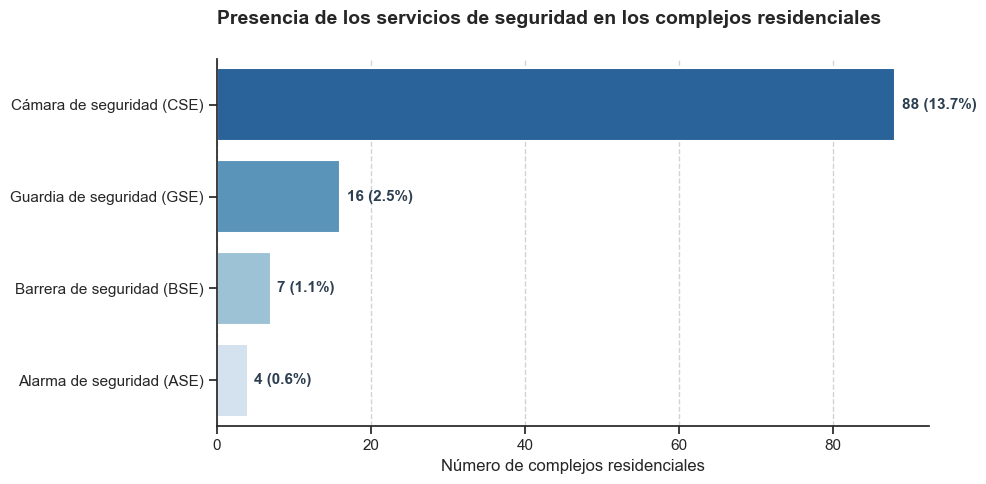

In [28]:
# Convert the variables to integers
seg_cols = ["GSE", "CSE", "BSE", "ASE"]
df[seg_cols] = df[seg_cols].astype(int)
# # Copy of dataframe for EDA of the variables in this block
df_seg = df[seg_cols+["URB_label"]].copy()
plot_variable_occurrences(df_seg, seg_cols, title="Presencia de los servicios de seguridad en los complejos residenciales",
                               dict_label={
                                        "GSE": "Guardia de seguridad (GSE)",
                                        "CSE": "Cámara de seguridad (CSE)",
                                        "BSE": "Barrera de seguridad (BSE)",
                                        "ASE": "Alarma de seguridad (ASE)"})

Los servicios y mecanismos de seguridad tienen una baja presencia en la base de datos. Las *cámaras de seguridad (CSE)* aparecen en un $13.7\%$ de los casos, mientras que la presencia de otros mecanismos como *alarma (ASE)*, *guardia (GSE)* o *barrera de seguridad (BSE)* se limita al $4.2\%$ de los complejos residenciales.

Las siguientes figuras muestran el análisis bivariante entre los mecanismos de seguridad y el grado de cerramiento. Las variables de este bloque presentan un comportamiento consistente, con una mayor presencia en la categoría *Protegido*, correspondiente al grado de cerramiento con mayor intensidad de cerramiento.

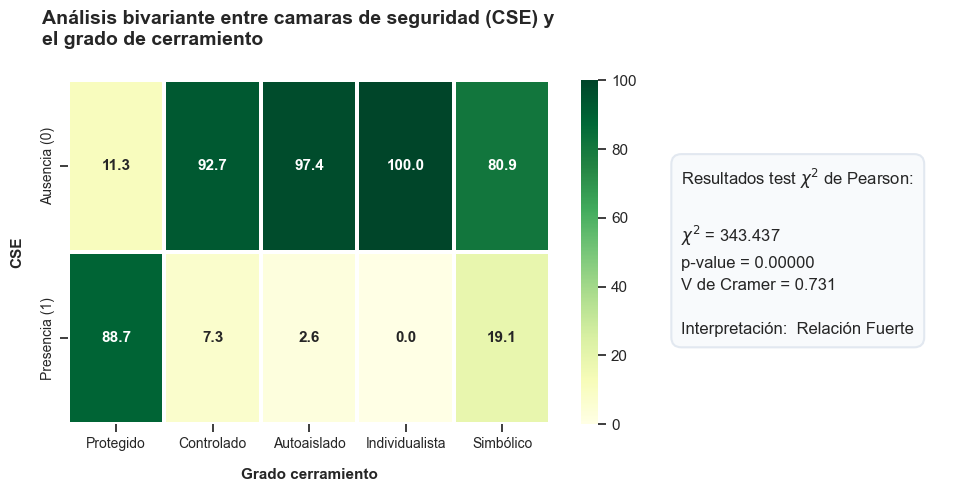

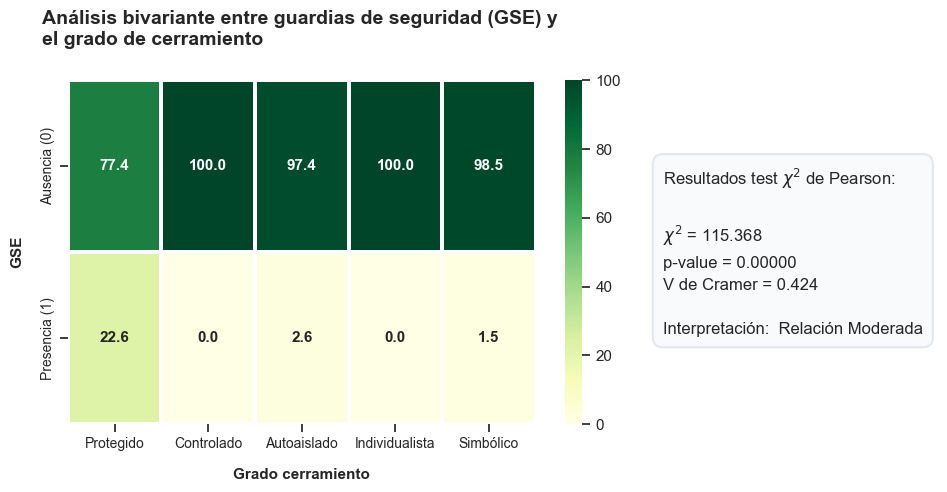

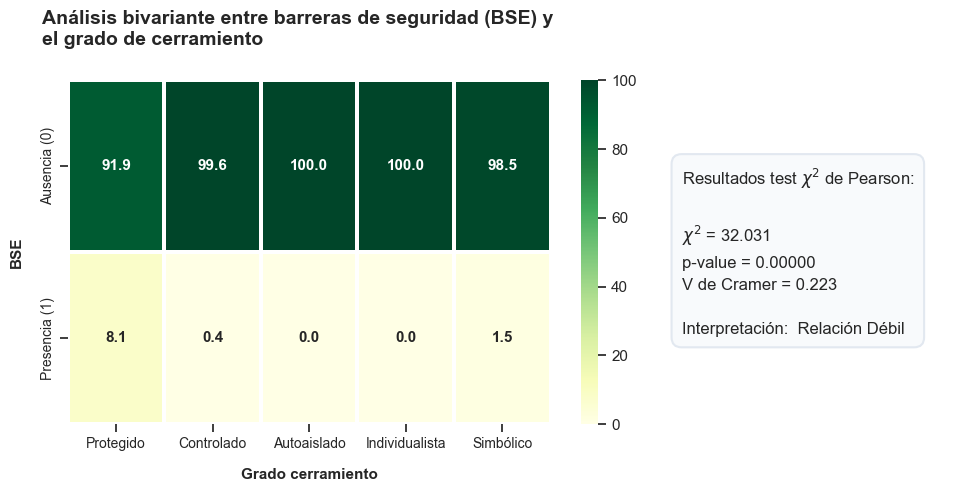

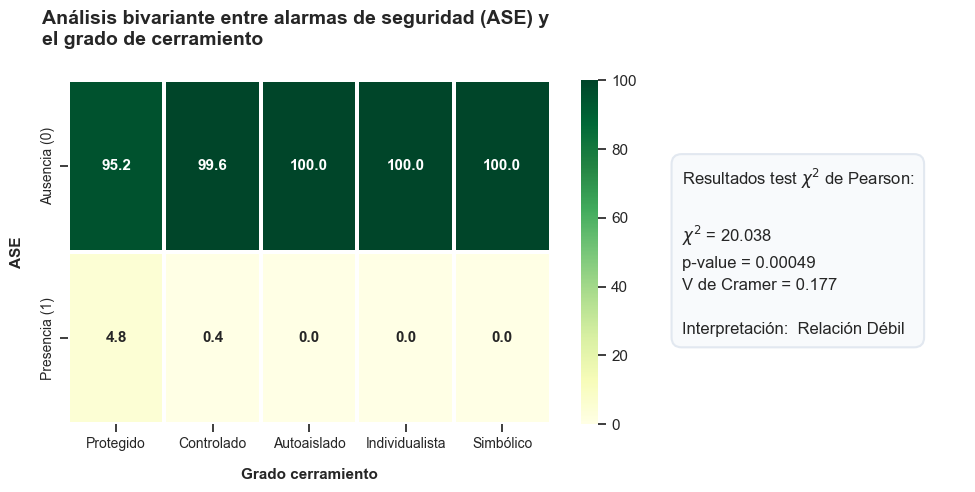

In [29]:
categorical_bivariate_analysis(df_seg, "URB_label", "CSE", "Análisis bivariante entre camaras de seguridad (CSE) y\nel grado de cerramiento", name_var_dep="Grado cerramiento")
categorical_bivariate_analysis(df_seg, "URB_label", "GSE", "Análisis bivariante entre guardias de seguridad (GSE) y\nel grado de cerramiento", name_var_dep="Grado cerramiento")
categorical_bivariate_analysis(df_seg, "URB_label", "BSE", "Análisis bivariante entre barreras de seguridad (BSE) y\nel grado de cerramiento", name_var_dep="Grado cerramiento")
categorical_bivariate_analysis(df_seg, "URB_label", "ASE", "Análisis bivariante entre alarmas de seguridad (ASE) y\nel grado de cerramiento", name_var_dep="Grado cerramiento")

El test $\chi^2$ de Pearson rechaza la hipótesis de independencia en las cuatro asociaciones analizadas. Sin embargo, el coeficiente V de Cramer muestra que únicamente las *cámaras de seguridad (CSE)* presentan una asociación fuerte. Esta diferencia entre significación e intensidad de asociación se explica, en parte, por la mayor frecuencia de aparición de esta característica, que proporciona una mayor evidencia estadística para detectar relaciones significativas.

Puede concluirse que los servicios de seguridad presentan una fuerte asociación con la categoría *Protegido*. No obstante, la existencia de *cámaras de seguridad (CSE)* en un $19.1\%$ de los complejos residenciales *Simbólicos* muestra que este elemento no permite identificar por sí solo el grado de cerramiento. La presencia de una misma característica en categorías con niveles de cerramiento opuestos evidencia que la morfología urbana de los grados de cerramiento no puede definirse a partir de un conjunto homogéneo de elementos aislados, sino mediante la combinación de múltiples características.

<a id="variable_predictoras_correlacion"></a>
# 5. Análisis de dependencia entre variables predictoras

Tras caracterizar individualmente las variables predictoras y analizar su relación de asociación con la variable objetivo, se estudia la dependencia existente entre las propias características. El objetivo de este análisis es identificar posibles dependencias entre variables predictoras que puedan indicar información redundante o características que describen patrones morfológicos similares. Este análisis permite comprender la estructura del conjunto de datos y considerar estas relaciones durante la interpretación de los modelos de clasificación.

Para cuantificar la relación entre variables se emplea el coeficiente de correlación $\phi$, una medida estadística que permite evaluar la asociación entre dos variables binarias. Este coeficiente es equivalente al coeficiente de correlación de Pearson cuando ambas variables toman valores $0$ y $1$, como ocurre en las variables categóricas binarias de la base de datos. 

La siguiente figura muestra la matriz de correlación $\phi$, mientras que la tabla recoge las asociaciones más relevantes, seleccionadas mediante un umbral de correlación en valor absoluto superior a $0.45$.

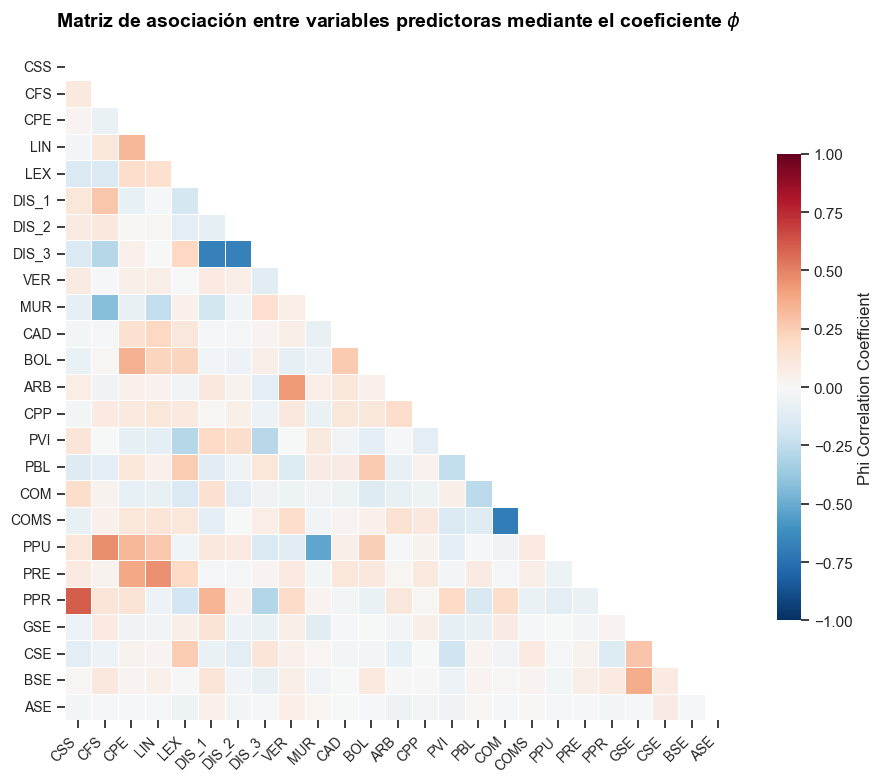

Variables with correlation coefficient |Phi| > 0.45:
Variable_1 Variable_2    Phi
       CSS        PPR  0.607
       CFS        PPU  0.465
       LIN        PRE  0.458
       MUR        PPU -0.530
     DIS_1      DIS_3 -0.675
     DIS_2      DIS_3 -0.675
       COM       COMS -0.700


In [30]:
# # Select independent variables
col_struct = ["CSS", "CFS", "CPE", "LIN", "LEX"]
col_dist = ["DIS_1", "DIS_2", "DIS_3"]
col_enclosure = ["VER", "MUR", "CAD", "BOL", "ARB", "CPP"]
col_access = ["PVI", "PBL", "COM", "COMS"]
col_via = ["PPU", "PRE", "PPR"]
col_seg = ["GSE", "CSE", "BSE", "ASE"]
X = df[col_struct + col_dist + col_enclosure + col_access + col_via + col_seg]

# Plot correlation matrix 
phi_corr_df = phi_correlation(X)

La matriz de asociación $\phi$ presenta, de forma general, valores próximos a cero entre la mayoría de pares de variables predictoras, lo que indica una baja dependencia entre características y una limitada presencia de información redundante en el conjunto de datos.

Se destacan algunas asociaciones negativas elevadas, concretamente entre los pares *DIS_1-DIS_3*, *DIS_2-DIS_3* y *COM-COMS*. Estos valores se explican por la naturaleza mutuamente excluyente de dichas variables, ya que la presencia de una categoría implica necesariamente la ausencia de la otra. El resto de asociaciones presenta valores moderados, siendo la mayor correlación en valor absoluto de $\phi=0.6$ lo que refuerza la idea de que las variables predictoras aportan información diferenciada.

Entre las relaciones más destacables se encuentra la asociación entre las *calles sin salida (CSS)* y las *calles en fondo de saco (CFS)* con diferentes usos de la vía. Este resultado sugiere que, aunque ambos elementos presentan una función disuasoria similar, aparecen vinculados a configuraciones viarias distintas, aportando información complementaria para caracterizar la categoría de cerramiento *Autoaislado*, donde estas variables muestran una mayor presencia.

<a id="construccion_datos"></a>
# 6. Construcción de los conjuntos de datos de trabajo

Tras realizar el análisis exploratorio de la base de datos, se construyen dos conjuntos de datos diferenciados, cada uno con un propósito específico dentro del flujo de trabajo. Ambos conjuntos incorporan la variable **CC**, que actúa como identificador único y permite establecer la correspondencia entre ellos cuando sea necesario.

* **descriptive_data**. Este conjunto de datos contiene todas las variables descriptivas. Esta información se utilizará con fines analíticos o para desarrollar visualizaciones sobre los resultados obtenidos.

* **model_data**. Este conjunto de datos contiene todas las variables independientes (predictoras), junto con la variable dependiente. Este *dataset* constituye la matriz de datos preparada para entrenar y evaluar los modelos de aprendizaje automático.

<a id="datos_descriptivos"></a>
## 6.1 Conjunto de datos descriptivo

Este conjunto de datos incluye las variables descriptivas o informativas. A continuación, se presentan los bloques temáticos incluidos en este conjunto de datos, junto con las variables que componen cada uno de ellos.

**Información general**

- **CC**. Identificador único del complejo residencial.
- **MUN**. Municipio para tareas de visualización o agrupamiento.
- **LAT y LON**. Las coordenadas de latitud y longitud son utilizadas para tareas de visualización.

**Características básicas**

- **AñoFin**. Año en el que finaliza la construcción del complejo residencial. Esta variable es renombrada a YEAR para evitar el uso del caracter Ñ.
- **SUP**. Superficie ocupada por el complejo residencial en metros cuadrados.
- **NVIV**. Número de viviendas que componen el complejo residencial.

**Tipo de residencia**

* **VAI**. Viviendas unifamiliares aisladas.
* **VPA**. Viviendas unifamiliares pareadas y otras.
* **VAD**. Viviendas unifamiliares adosadas.
* **PMC**. Pisos en manzana cerrada.
* **PMA**. Pisos en manzana abierta.
* **CON**. En construcción.

**Equipamientos comunes**

* **PIS**. Piscina.
* **PTP**. Pista de Tenis/Padel.
* **PBA**. Pista de Baloncesto.
* **CFU**. Campo de fútbol.
* **CGO**. Campo de Golf.
* **GIM**. Gimnasio.
* **PAR**. Parque Infantil.
* **MOB**. Patio con Mobiliario.
* **JAR**. Jardines/Parques.

In [31]:
# Dataset creation
info_cols = ["CC", "MUN", "LAT", "LON"]
basic_cols = ["AñoFin", "SUP", "NVIV"]
res_cols = ["VAI", "VPA", "VAD", "PMC", "PMA", "CON"]
equip_cols = ["PIS","PTP","PBA", "CFU", "CGO", "GIM", "PAR", "MOB", "JAR"]
descriptive_df = df[info_cols+basic_cols+res_cols+equip_cols+["URB"]].copy().rename(columns={"AñoFin": "YEAR"})
print("Descriptive data set (first five rows)")
descriptive_df.head()

Descriptive data set (first five rows)


,CC,MUN,LAT,LON,YEAR,SUP,NVIV,VAI,VPA,VAD,PMC,PMA,CON,PIS,PTP,PBA,CFU,CGO,GIM,PAR,MOB,JAR,URB
0,301014,ALBOLOTE,440856.399,4126716.381,2011,14519.63,61,0,1,1,0,0,0,0,1,0,0,0,0,1,1,1,1
1,301015,ALBOLOTE,440502.598,4126703.923,1986,6190.15,13,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,4
2,301016,ALBOLOTE,440487.649,4126771.195,1986,5006.58,10,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,4
3,301017,ALBOLOTE,440549.938,4126833.484,1986,5196.59,10,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,4
4,301018,ALBOLOTE,440597.277,4126783.653,1986,5079.12,10,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,4


In [32]:
descriptive_path = cfg.DATA_PROCESSED_DIR/"descriptive_data.csv"
descriptive_df.to_csv(descriptive_path, index=False, encoding="utf-8")
print(f"DataFrame stored in {descriptive_path}.")

DataFrame stored in C:\Users\david\Documents\MASTER_CIENCIA_DE_DATOS\TFM\PROJECT\data\processed\descriptive_data.csv.


<a id="model_data"></a>
## 6.2 Conjunto de datos para entrenamiento y evaluación de modelos

Este conjunto de datos incluye todas las variables independientes (predictoras) junto con la variable dependiente (objetivo). Este es el conjunto de datos utilizado para entrenar y evaluar los modelos de aprendizaje automático.

Se incluye la variable **CC**, que actúa como identificador único de cada complejo residencial. Aunque esta variable no participa en el proceso de modelado, se conserva con el fin de mantener la trazabilidad de los registros y facilitar la vinculación con el conjunto de datos *descriptive_data*. De este modo, es posible recuperar en cualquier momento la información descriptiva asociada a cada observación para su posterior análisis e interpretación de resultados.

A continuación, se presentan los bloques temáticos incluidos en este conjunto de datos, junto con las variables que componen cada uno de ellos.

**Información general**
* **CC**. Identificador único del complejo residencial.

**Aspectos estructurales**
* **CSS**. Calles sin salida.
* **CFS**. Calles en fondo de saco.
* **CPE**. Calle peatonal.
* **LIN**. Comercios internos.
* **LEX**. Comercios externos.

**Distancia al núcleo urbano principal**
* **DIS_1**. Representa la categoría *Urbanización aislada*.
* **DIS_2**. Representa la categoría *Urbanización separada*.
* **DIS_3**. Representa la categoría *Urbanización integrada en casco urbano*.

**Tipo de Cerramiento**
* **VER**. Verjas o Vallas.
* **MUR**. Muros.
* **CAD**. Cadenas.
* **BOL**. Bolardos.
* **ARB**. Arbustos.
* **CPP**. Carteles de propiedad privada.

**Puntos de acceso**
* **PVI**. Entrada por vivienda.
* **PBL**. Entrada por bloque.
* **COM**. Entrada común a la urbanización
* **COMS**. Varias entradas comunes a la urbanización.

**Uso de vía pública**
* **PPU**. Dominio público y de uso público.
* **PRE**. Dominio privado de uso público restringido.
* **PPR**. Dominio privado de uso privado.

**Seguridad y vigilancia**
* **GSE**. Guardia de seguridad.
* **CSE**. Cámaras de seguridad.
* **BSE**. Barrera de seguridad.
* **ASE**. Alarma de seguridad.

**Variable objetivo: Clasificación de referencia**
* **URB**. Clasificación tipológica de cerramiento.

In [34]:
valid_df = df[["CC"]+col_struct+col_dist+col_enclosure+col_access+col_via+col_seg+["URB"]].copy()
print(f"Number of predictive variables{valid_df.shape[1]-2}")
valid_df.head()

Number of predictive variables25


,CC,CSS,CFS,CPE,LIN,LEX,DIS_1,DIS_2,DIS_3,VER,MUR,CAD,BOL,ARB,CPP,PVI,PBL,COM,COMS,PPU,PRE,PPR,GSE,CSE,BSE,ASE,URB
0,301014,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,1,0,1
1,301015,0,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,4
2,301016,0,0,0,0,0,1,0,0,1,1,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,4
3,301017,0,0,0,0,0,1,0,0,1,1,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,4
4,301018,0,0,0,0,0,1,0,0,1,1,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,4


In [35]:
model_data_path = cfg.DATA_PROCESSED_DIR/"model_data.csv"
valid_df.to_csv(model_data_path, index=False, encoding="utf-8")
print(f"DataFrame almacenado en {model_data_path}.")

DataFrame almacenado en C:\Users\david\Documents\MASTER_CIENCIA_DE_DATOS\TFM\PROJECT\data\processed\model_data.csv.
